# Progetto pratico — Scienza ed etica dei dati

## Analisi etica del dataset ACSIncome

**Autori**: Riccardo Romano (matricola 2126461) · Hera Polegri (matricola 2153537)

## Sezione 0 — Setup ambiente

Questa sezione prepara l'ambiente di esecuzione su Google Colab: installa le librerie non preinstallate, importa tutti i moduli usati nel notebook, fissa i seed per la riproducibilità e stampa le versioni delle dipendenze principali.

In [1]:
# Installazione librerie non preinstallate su Colab.
# pandas, numpy, scikit-learn, matplotlib, scipy sono già disponibili.
!pip install -q folktables fairlearn shap lime imbalanced-learn diffprivlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 24.3 MB/s eta 0:00:00


In [2]:
# Import standard e scientific stack
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# scikit-learn: preprocessing, modelli, valutazione
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

# Dataset e moduli etici
import folktables
from folktables import ACSDataSource, ACSIncome

import fairlearn
from fairlearn.metrics import MetricFrame
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds, TruePositiveRateParity
from fairlearn.postprocessing import ThresholdOptimizer

import shap
import lime
import lime.lime_tabular

import diffprivlib
from diffprivlib.mechanisms import Laplace

# Riproducibilità: seed globali
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Sopprime i FutureWarning / DeprecationWarning non bloccanti
# (shap e diffprivlib ne generano diversi su scikit-learn recente)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Estetica plot
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_palette("colorblind")

In [3]:
# Stampa versioni librerie principali per riproducibilità
import sys
import sklearn
import importlib.metadata

def get_version(module, name=None):
    """Restituisce la versione di una libreria.
    Prova prima module.__version__, poi importlib.metadata per
    le librerie che non espongono __version__ (es. lime).
    """
    try:
        return module.__version__
    except AttributeError:
        return importlib.metadata.version(name or module.__name__)

versions = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "fairlearn": fairlearn.__version__,
    "shap": shap.__version__,
    "lime": get_version(lime, "lime"),
    "diffprivlib": diffprivlib.__version__,
    "folktables": get_version(folktables, "folktables"),
}

for name, ver in versions.items():
    print(f"{name:>14s}: {ver}")

        python: 3.12.13
         numpy: 2.0.2
        pandas: 2.2.2
  scikit-learn: 1.6.1
     fairlearn: 0.13.0
          shap: 0.51.0
          lime: 0.2.0.1
   diffprivlib: 0.6.6
    folktables: 0.0.12


### Sezione 1 — Introduzione e framing etico

Il dataset ACSIncome — derivato dall'American Community Survey del U.S. Census Bureau — nasce per uno scopo statistico-aggregato: descrivere la struttura economica della popolazione. Da quando Ding, Hardt, Miller e Schmidt (2021) lo hanno proposto come benchmark per la ricerca su fairness, è diventato un terreno su cui vengono addestrati modelli predittivi reimpiegabili, in linea di principio, per scoring creditizio o valutazione assicurativa. Questo passaggio — da dato pubblico ad alta granularità a modello operativo su decisioni individuali — è il caso paradigmatico della **dual-use dei dati**: l'oggetto è uno, le sue conseguenze etiche sono due.

Questo progetto si colloca esattamente in quel passaggio. Non costruiamo un sistema di produzione, ma compiamo l'audit che andrebbe compiuto **prima** che un sistema del genere venga messo in funzione. Affrontiamo due aree etiche: **bias ed equità** (parte A) e **protezione della privacy** (parte B); l'interpretabilità via SHAP e LIME è trattata come strumento interno all'audit di bias. L'area di *autenticità umano/artificiale* resta fuori dallo scope per coerenza con il tipo di dato.

Il framing adottato è quello dell'*etica interna al design*: non una verifica di conformità a posteriori, ma una serie di scelte tecniche che incorporano valori nel processo stesso. Metriche di fairness, mitigazione del bias, k-anonymity e differential privacy non sono *soluzioni* a un problema etico esterno: sono **strumenti che abilitano scelte etiche**. Quale definizione di fairness adottare, quale ε di privacy accettare, quale trade-off privilegiare — sono questioni che la tecnica permette di formulare con precisione, ma che richiedono un giudizio che la tecnica non può sostituire.

Il punto di arrivo è la verifica di un'ipotesi: quando si cerca contemporaneamente di mitigare il bias, proteggere la privacy e mantenere l'utility di un modello, si incontra un **trilemma** strutturale che la sezione 14 affronta esplicitamente.

## Sezione 2 — Dataset: descrizione e attributi

**ACSIncome** è un benchmark proposto da Ding, Hardt, Miller e Schmidt nel paper *Retiring Adult: New Datasets for Fair Machine Learning* (NeurIPS 2021), pensato come sostituto moderno del classico UCI Adult. È derivato dall'**American Community Survey** (ACS) del U.S. Census Bureau, un'indagine annuale sulla popolazione statunitense con un campione molto più ampio, recente e dettagliato del census decennale.

Il **task** è una classificazione binaria: dato il profilo socio-economico di un individuo, prevedere se il reddito personale (`PINCP`) supera i 50.000 USD all'anno.

Lavoriamo su **due stati**: **California** (alto reddito medio, alta diversità etnica, costo della vita elevato) e **Mississippi** (basso reddito medio, demografia molto diversa, contesto socio-economico opposto). Questo confronto è il cuore della narrativa **context-dependent fairness**: vogliamo verificare se il bias che misureremo nelle sezioni successive è una proprietà del modello/dato in sé o se dipende sensibilmente dal contesto in cui viene applicato.

Nella tabella alla fine di questa sezione classifichiamo ogni colonna in tre categorie: **target**, **attributi sensibili** (centro della Parte A — Bias) e **quasi-identificatori** (centro della Parte B — Privacy).

In [4]:
# Configurazione della fonte dati ACS (American Community Survey 2018, 1-Year)
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')

# Scaricamento separato per CA e MS, con aggiunta manuale della colonna STATE
# (df_to_pandas scarta la colonna ST perché non è feature del task ACSIncome).
features_per_state = []
labels_per_state = []

for stato in ['CA', 'MS']:
    # Download dei dati grezzi dello stato
    raw = data_source.get_data(states=[stato], download=True)
    # Estrazione di (features, label, group) secondo la specifica ACSIncome
    feat_df, lab_df, _ = ACSIncome.df_to_pandas(raw)
    # Aggiunta colonna narrativa STATE (valore costante per ogni stato)
    feat_df = feat_df.copy()
    feat_df['STATE'] = stato
    features_per_state.append(feat_df)
    labels_per_state.append(lab_df)

# Concatenazione dei due stati in un unico dataset
features_full = pd.concat(features_per_state, ignore_index=True)
label_full = pd.concat(labels_per_state, ignore_index=True)

# Verifica di coerenza tra features e label
assert len(features_full) == len(label_full), "Mismatch features/label"

# Riepilogo del dataset completo (pre-subsample)
print(f"Shape totale features: {features_full.shape}")
print(f"Shape totale label:    {label_full.shape}")
print(f"\nDistribuzione per STATE:\n{features_full['STATE'].value_counts()}")
print(f"\nDistribuzione target (income > 50k):\n{label_full.iloc[:, 0].value_counts(normalize=True).round(3)}")

Shape totale features: (208854, 11)
Shape totale label:    (208854, 1)

Distribuzione per STATE:
STATE
CA    195665
MS     13189
Name: count, dtype: int64

Distribuzione target (income > 50k):
PINCP
False    0.598
True     0.402
Name: proportion, dtype: float64


In [5]:
# Subsample stratificato bilanciato CA/MS
# Mississippi è significativamente più piccolo della California:
# prendiamo tutti i record di MS disponibili e poi un campione di pari
# dimensione da CA. Questo massimizza l'informazione disponibile pur
# mantenendo il bilanciamento CA/MS necessario al confronto context-dependent.

state_counts = features_full['STATE'].value_counts()
print(f"Dimensione per stato (dataset completo):\n{state_counts}\n")

n_per_state = state_counts.min()
print(f"N per stato (= min tra CA e MS): {n_per_state:,}")
print(f"Subsample totale atteso: {2 * n_per_state:,}\n")

sampled_idx = (
    features_full
    .groupby('STATE', group_keys=False)
    .apply(lambda g: g.sample(n=n_per_state, random_state=SEED))
    .index
)

df_features = features_full.loc[sampled_idx].reset_index(drop=True)
df_label = label_full.loc[sampled_idx].reset_index(drop=True)

# Verifiche finali
assert len(df_features) == 2 * n_per_state
assert len(df_label) == 2 * n_per_state
assert (df_features['STATE'].value_counts() == n_per_state).all()

print(f"Shape df_features: {df_features.shape}")
print(f"Shape df_label:    {df_label.shape}")
print(f"\nBilanciamento STATE (subsample):\n{df_features['STATE'].value_counts()}")
print(f"\nDistribuzione target nel subsample:\n{df_label.iloc[:, 0].value_counts(normalize=True).round(3)}")

Dimensione per stato (dataset completo):
STATE
CA    195665
MS     13189
Name: count, dtype: int64

N per stato (= min tra CA e MS): 13,189
Subsample totale atteso: 26,378

Shape df_features: (26378, 11)
Shape df_label:    (26378, 1)

Bilanciamento STATE (subsample):
STATE
CA    13189
MS    13189
Name: count, dtype: int64

Distribuzione target nel subsample:
PINCP
False    0.66
True     0.34
Name: proportion, dtype: float64


In [6]:
# Classificazione esplicita di ogni colonna del dataset secondo le 4 categorie
# usate nel progetto: target, sensibile (Parte A), quasi-ID (Parte B), normale.
attr_classification = [
    ('PINCP',  'target',               'Reddito personale binarizzato (> 50.000 USD)'),
    ('SEX',    'sensibile',            'Sesso (1 = maschio, 2 = femmina)'),
    ('RAC1P',  'sensibile',            'Race code (1-9, categoriale)'),
    ('AGEP',   'quasi-identificatore', 'Età in anni'),
    ('SCHL',   'quasi-identificatore', 'Livello di istruzione (categoriale ordinato)'),
    ('OCCP',   'quasi-identificatore', 'Codice occupazione (categoriale ad alta cardinalità)'),
    ('POBP',   'quasi-identificatore', 'Place of birth (luogo di nascita)'),
    ('MAR',    'quasi-identificatore', 'Stato civile (marital status)'),
    ('COW',    'feature normale',      'Class of worker (settore di impiego)'),
    ('RELP',   'feature normale',      'Relazione con persona di riferimento del nucleo'),
    ('WKHP',   'feature normale',      'Ore settimanali lavorate (usual hours worked)'),
    ('STATE',  'feature normale',      'Codice stato (CA / MS) — variabile narrativa'),
]
attr_table = pd.DataFrame(attr_classification, columns=['feature', 'tipo', 'descrizione'])
print(attr_table.to_string(index=False))

feature                 tipo                                          descrizione
  PINCP               target         Reddito personale binarizzato (> 50.000 USD)
    SEX            sensibile                     Sesso (1 = maschio, 2 = femmina)
  RAC1P            sensibile                         Race code (1-9, categoriale)
   AGEP quasi-identificatore                                          Età in anni
   SCHL quasi-identificatore         Livello di istruzione (categoriale ordinato)
   OCCP quasi-identificatore Codice occupazione (categoriale ad alta cardinalità)
   POBP quasi-identificatore                    Place of birth (luogo di nascita)
    MAR quasi-identificatore                        Stato civile (marital status)
    COW      feature normale                 Class of worker (settore di impiego)
   RELP      feature normale      Relazione con persona di riferimento del nucleo
   WKHP      feature normale        Ore settimanali lavorate (usual hours worked)
  STATE      fea

La distinzione tra **attributi sensibili** e **quasi-identificatori** è il cardine metodologico del progetto: i primi (`SEX`, `RAC1P`) sono il bersaglio dell'audit di fairness nella Parte A, perché definiscono i sottogruppi rispetto ai quali misuriamo disparate impact, equal opportunity ecc.; i secondi (`AGEP`, `SCHL`, `OCCP`, `POBP`, `MAR`) sono il bersaglio della Parte B, perché abilitano attacchi di re-identificazione anche su un dataset apparentemente anonimo. La colonna `STATE` non rientra in nessuna delle due categorie: non è un attributo sensibile in senso GDPR né un quasi-ID realistico, è una **variabile narrativa** che useremo solo per il confronto contestuale CA vs MS.

## Sezione 3 — EDA quantitativa

Questa sezione applica tecniche di **analisi della distribuzione dei dati**: distribuzione delle frequenze, distribuzione condizionata, visualizzazioni comparative, analisi di densità, test statistici (Chi-quadro, Kolmogorov-Smirnov, t-test).

L'obiettivo non è descrivere il dataset in modo generico, ma cercare **segnali concreti di disparità**: differenze nella distribuzione del target tra gruppi sensibili (`SEX`, `RAC1P`) e tra i due stati (`CA`, `MS`). Sono questi segnali a giustificare — o a smentire — l'ipotesi di bias che la Parte A approfondirà con metriche di fairness e mitigazione.

In [7]:
# Estrazione del target come Series booleana per comodità
target = df_label.iloc[:, 0]  # colonna 'PINCP' binarizzata

# Distribuzione frequenze: target globale e attributi sensibili / contestuali
print("=== Distribuzione target (income > 50k) ===")
print(target.value_counts(normalize=True).round(3))

print("\n=== Distribuzione SEX (1=M, 2=F) ===")
print(df_features['SEX'].value_counts(normalize=True).round(3))

print("\n=== Distribuzione RAC1P (1-9) ===")
print(df_features['RAC1P'].value_counts(normalize=True).round(3).sort_index())

print("\n=== Distribuzione STATE (atteso ~50/50 per costruzione) ===")
print(df_features['STATE'].value_counts(normalize=True).round(3))

=== Distribuzione target (income > 50k) ===
PINCP
False    0.66
True     0.34
Name: proportion, dtype: float64

=== Distribuzione SEX (1=M, 2=F) ===
SEX
1.0    0.518
2.0    0.482
Name: proportion, dtype: float64

=== Distribuzione RAC1P (1-9) ===
RAC1P
1.0    0.638
2.0    0.173
3.0    0.005
5.0    0.001
6.0    0.093
7.0    0.002
8.0    0.063
9.0    0.025
Name: proportion, dtype: float64

=== Distribuzione STATE (atteso ~50/50 per costruzione) ===
STATE
CA    0.5
MS    0.5
Name: proportion, dtype: float64


In [8]:
# DataFrame di comodo: features + target affiancati per le tabelle condizionate
df_eda = df_features.copy()
df_eda['target'] = target.values

# P(target=True | gruppo) per ogni attributo di interesse
print("=== P(income>50k | SEX) ===")
print(df_eda.groupby('SEX')['target'].mean().round(3))

print("\n=== P(income>50k | RAC1P) ===")
print(df_eda.groupby('RAC1P')['target'].mean().round(3).sort_index())

print("\n=== P(income>50k | STATE) ===")
print(df_eda.groupby('STATE')['target'].mean().round(3))

# Incroci a 2 dimensioni: SEX × STATE e RAC1P × STATE
print("\n=== P(income>50k | SEX × STATE) ===")
print(df_eda.groupby(['SEX', 'STATE'])['target'].mean().unstack().round(3))

print("\n=== P(income>50k | RAC1P × STATE) ===")
print(df_eda.groupby(['RAC1P', 'STATE'])['target'].mean().unstack().round(3))

=== P(income>50k | SEX) ===
SEX
1.0    0.411
2.0    0.264
Name: target, dtype: float64

=== P(income>50k | RAC1P) ===
RAC1P
1.0    0.381
2.0    0.179
3.0    0.231
5.0    0.167
6.0    0.478
7.0    0.140
8.0    0.190
9.0    0.334
Name: target, dtype: float64

=== P(income>50k | STATE) ===
STATE
CA    0.411
MS    0.270
Name: target, dtype: float64

=== P(income>50k | SEX × STATE) ===
STATE     CA     MS
SEX                
1.0    0.462  0.357
2.0    0.353  0.180

=== P(income>50k | RAC1P × STATE) ===
STATE     CA     MS
RAC1P              
1.0    0.441  0.325
2.0    0.342  0.156
3.0    0.289  0.132
5.0    0.194  0.000
6.0    0.496  0.261
7.0    0.159  0.000
8.0    0.193  0.151
9.0    0.353  0.256


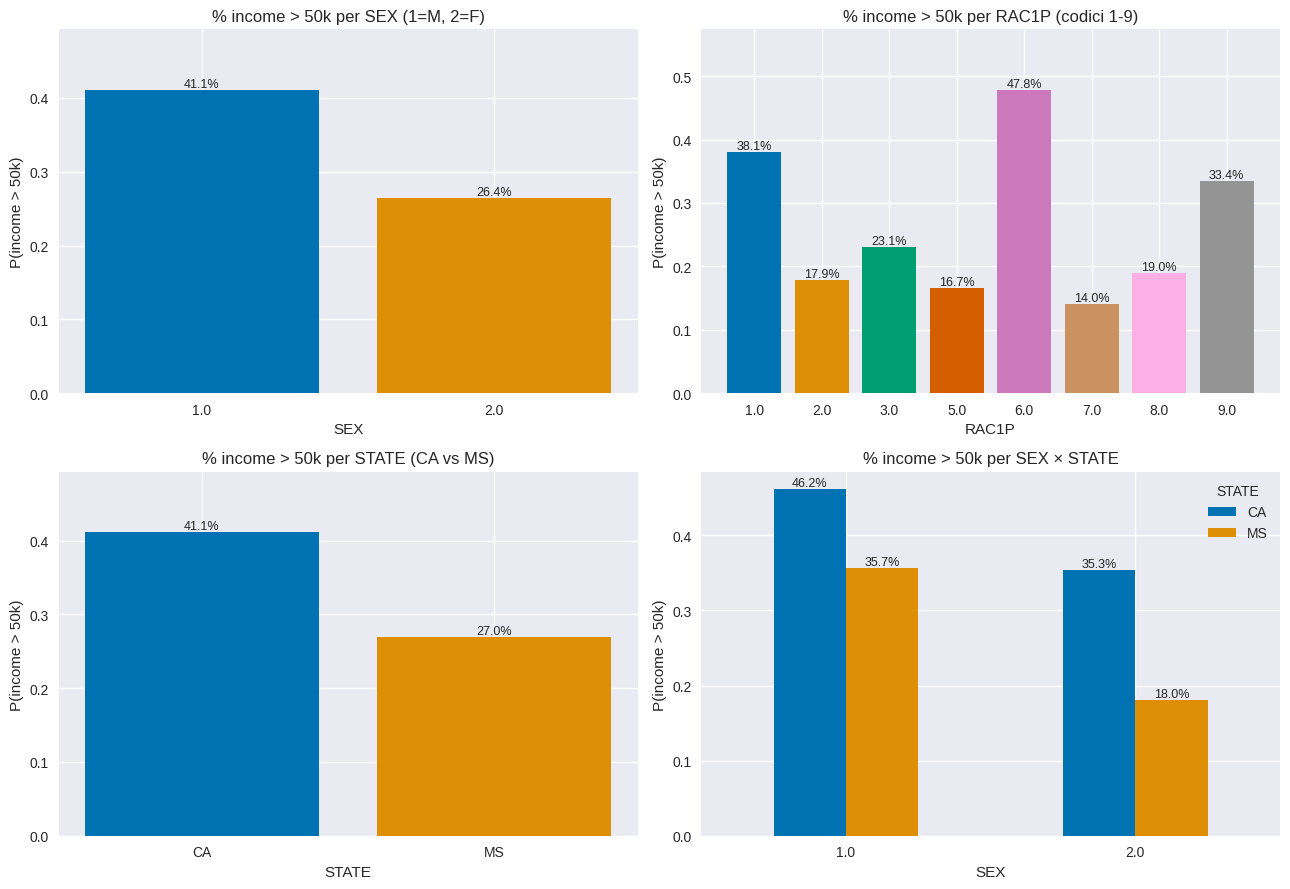

In [9]:
# Visualizzazioni comparative: 4 bar plot in griglia 2x2
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = sns.color_palette('colorblind')

def annotate_bars(ax, fmt='{:.1%}'):
    """Scrive il valore percentuale sopra ogni barra."""
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=9)

# (0,0) % target=True per SEX
rate_sex = df_eda.groupby('SEX')['target'].mean()
axes[0, 0].bar(rate_sex.index.astype(str), rate_sex.values, color=palette[:len(rate_sex)])
axes[0, 0].set_title('% income > 50k per SEX (1=M, 2=F)')
axes[0, 0].set_xlabel('SEX')
axes[0, 0].set_ylabel('P(income > 50k)')
axes[0, 0].set_ylim(0, max(rate_sex.values) * 1.2)
annotate_bars(axes[0, 0])

# (0,1) % target=True per RAC1P
rate_race = df_eda.groupby('RAC1P')['target'].mean().sort_index()
axes[0, 1].bar(rate_race.index.astype(str), rate_race.values, color=palette[:len(rate_race)])
axes[0, 1].set_title('% income > 50k per RAC1P (codici 1-9)')
axes[0, 1].set_xlabel('RAC1P')
axes[0, 1].set_ylabel('P(income > 50k)')
axes[0, 1].set_ylim(0, max(rate_race.values) * 1.2)
annotate_bars(axes[0, 1])

# (1,0) % target=True per STATE
rate_state = df_eda.groupby('STATE')['target'].mean()
axes[1, 0].bar(rate_state.index, rate_state.values, color=palette[:len(rate_state)])
axes[1, 0].set_title('% income > 50k per STATE (CA vs MS)')
axes[1, 0].set_xlabel('STATE')
axes[1, 0].set_ylabel('P(income > 50k)')
axes[1, 0].set_ylim(0, max(rate_state.values) * 1.2)
annotate_bars(axes[1, 0])

# (1,1) % target=True per SEX × STATE (raggruppato)
rate_sex_state = df_eda.groupby(['SEX', 'STATE'])['target'].mean().unstack()
rate_sex_state.plot(kind='bar', ax=axes[1, 1], color=[palette[0], palette[1]])
axes[1, 1].set_title('% income > 50k per SEX × STATE')
axes[1, 1].set_xlabel('SEX')
axes[1, 1].set_ylabel('P(income > 50k)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(title='STATE')
annotate_bars(axes[1, 1])

plt.tight_layout()
plt.show()

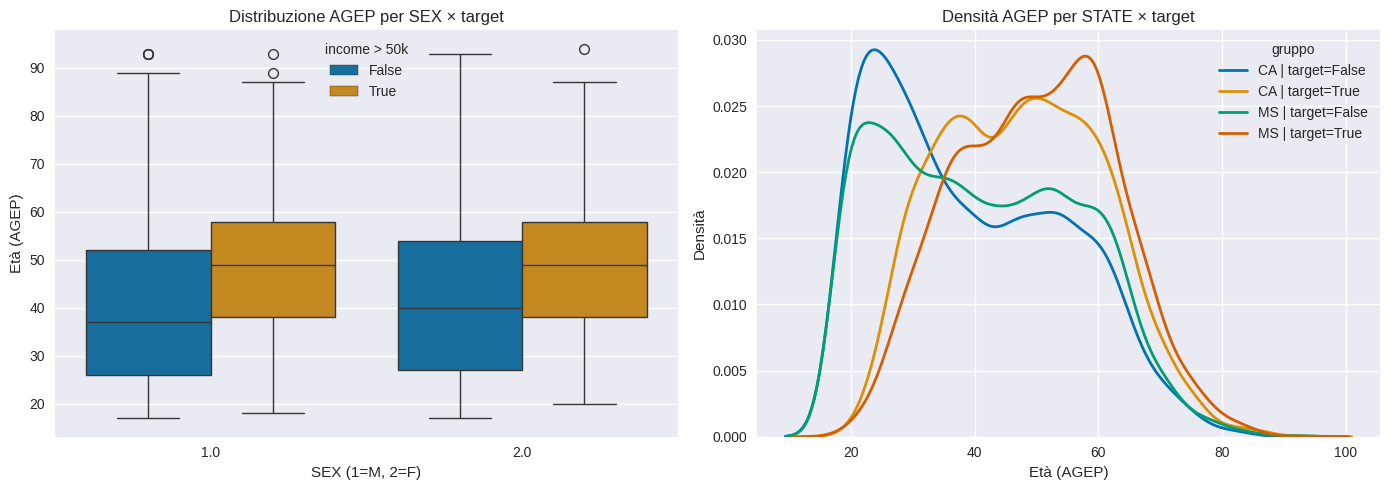

In [10]:
# Analisi di densità su AGEP: boxplot per SEX × target, KDE per STATE × target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sinistra: boxplot AGEP per combinazione SEX × target
sns.boxplot(
    data=df_eda, x='SEX', y='AGEP', hue='target',
    ax=axes[0], palette='colorblind',
)
axes[0].set_title('Distribuzione AGEP per SEX × target')
axes[0].set_xlabel('SEX (1=M, 2=F)')
axes[0].set_ylabel('Età (AGEP)')
axes[0].legend(title='income > 50k')

# Destra: KDE di AGEP per STATE × target (4 curve)
for stato in df_eda['STATE'].unique():
    for tgt in [False, True]:
        subset = df_eda[(df_eda['STATE'] == stato) & (df_eda['target'] == tgt)]
        sns.kdeplot(
            subset['AGEP'], ax=axes[1],
            label=f'{stato} | target={tgt}',
            fill=False, linewidth=2,
        )
axes[1].set_title('Densità AGEP per STATE × target')
axes[1].set_xlabel('Età (AGEP)')
axes[1].set_ylabel('Densità')
axes[1].legend(title='gruppo')

plt.tight_layout()
plt.show()

In [11]:
# Test statistici (slide bias 21): Chi-quadro su variabili categoriche,
# KS e t-test su variabili continue. p < 0.05 → distribuzioni diverse.
ALPHA = 0.05

def interp(p):
    return ("distribuzioni significativamente diverse"
            if p < ALPHA else "nessuna differenza significativa")

# Chi-quadro: indipendenza tra attributo categorico e target
print("=== Chi-quadro: SEX vs target ===")
ct = pd.crosstab(df_eda['SEX'], df_eda['target'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"chi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.3e} → {interp(p)}")

print("\n=== Chi-quadro: RAC1P vs target ===")
ct = pd.crosstab(df_eda['RAC1P'], df_eda['target'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"chi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.3e} → {interp(p)}")

print("\n=== Chi-quadro: STATE vs target ===")
ct = pd.crosstab(df_eda['STATE'], df_eda['target'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"chi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.3e} → {interp(p)}")

# Kolmogorov-Smirnov: confronto distribuzioni continue (AGEP) tra esiti
print("\n=== Kolmogorov-Smirnov: AGEP | target=True vs target=False ===")
age_pos = df_eda.loc[df_eda['target'] == True, 'AGEP']
age_neg = df_eda.loc[df_eda['target'] == False, 'AGEP']
ks_stat, p = stats.ks_2samp(age_pos, age_neg)
print(f"KS = {ks_stat:.3f}, p-value = {p:.3e} → {interp(p)}")

# t-test: medie di AGEP tra maschi e femmine
print("\n=== t-test: AGEP | SEX=1 (M) vs SEX=2 (F) ===")
age_m = df_eda.loc[df_eda['SEX'] == 1, 'AGEP']
age_f = df_eda.loc[df_eda['SEX'] == 2, 'AGEP']
t_stat, p = stats.ttest_ind(age_m, age_f, equal_var=False)
print(f"t = {t_stat:.2f}, p-value = {p:.3e} → {interp(p)}")
print(f"   media AGEP M = {age_m.mean():.2f}, F = {age_f.mean():.2f}")

=== Chi-quadro: SEX vs target ===
chi2 = 629.03, dof = 1, p-value = 8.121e-139 → distribuzioni significativamente diverse

=== Chi-quadro: RAC1P vs target ===
chi2 = 1046.75, dof = 7, p-value = 9.525e-222 → distribuzioni significativamente diverse

=== Chi-quadro: STATE vs target ===
chi2 = 586.78, dof = 1, p-value = 1.257e-129 → distribuzioni significativamente diverse

=== Kolmogorov-Smirnov: AGEP | target=True vs target=False ===
KS = 0.260, p-value = 0.000e+00 → distribuzioni significativamente diverse

=== t-test: AGEP | SEX=1 (M) vs SEX=2 (F) ===
t = 1.05, p-value = 2.945e-01 → nessuna differenza significativa
   media AGEP M = 43.26, F = 43.07


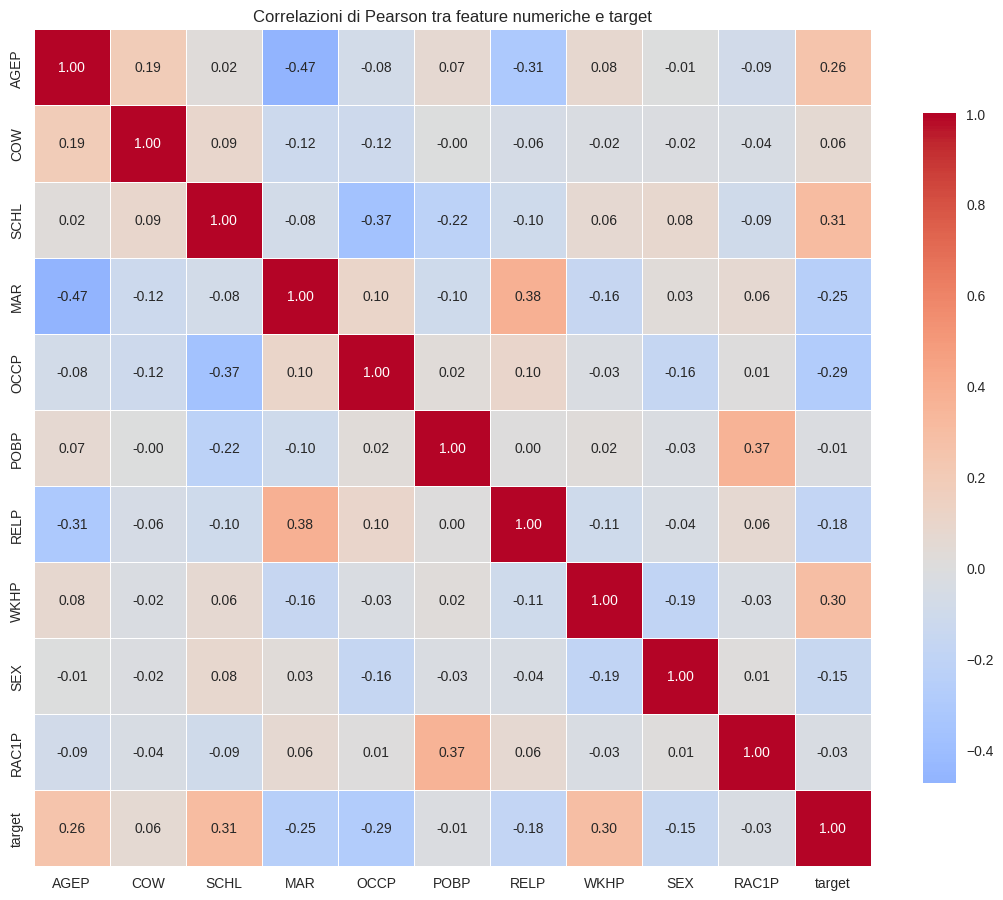

In [12]:
# Heatmap di correlazione su tutte le feature numeriche + target.
# STATE è esclusa perché stringa narrativa (non numerica).
num_cols = df_eda.select_dtypes(include='number').columns.tolist()
# Aggiungo il target (booleano → numerico) se non è già fra le numeriche
corr_df = df_eda[num_cols].copy()
corr_df['target'] = df_eda['target'].astype(int)

corr_matrix = corr_df.corr(method='pearson')

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
plt.title('Correlazioni di Pearson tra feature numeriche e target')
plt.tight_layout()
plt.show()

### Sintesi della Sezione 3

L'analisi rivela un pattern di **historical bias** multidimensionale, statisticamente significativo, con differenze sistematiche nei tassi di esito positivo (income > 50k) lungo le tre dimensioni sensibili.

**Gap di genere**: 14.7 punti percentuali (M: 41.1%, F: 26.4%; χ² p ≈ 10⁻¹³⁹). **Gap razziale**: ancora più marcato, con spread fra 14% (RAC1P=7) e 48% (RAC1P=6). **Gap inter-statale**: 14.1 punti (CA: 41.1%, MS: 27.0%). Il t-test su AGEP per SEX non è significativo (p = 0.29), escludendo l'età come confounder del gender gap.

Il dato chiave emerge dagli incroci: il gender gap in Mississippi (17.7pp) è quasi il doppio di quello in California (10.9pp). La fairness dipende dal contesto socio-economico in cui viene misurata, non è una proprietà invariante del modello.

La Sezione 4 misurerà quanto di questo bias venga preservato — o amplificato — dai modelli baseline.

## Sezione 4 — Modelli baseline

Questa sezione costruisce i modelli supervisionati di riferimento per tutto il resto del notebook. Addestriamo due classificatori con profili volutamente diversi: una **Logistic Regression**, interpretabile by design, e un **Gradient Boosting**, più potente ma sostanzialmente black-box. Il confronto serve sia da baseline numerica per le Sezioni 5-9, sia da illustrazione concreta del trade-off interpretabilità/performance che la Sezione 7 (SHAP/LIME) approfondisce.

Per scelta esplicita **non facciamo tuning degli iperparametri**: il focus del progetto è etico, non puramente predittivo. Usiamo default ragionevoli; il vero confronto avverrà sulle metriche di fairness, non sull'accuracy.

In [13]:
# X esclude STATE: è una variabile narrativa, non deve diventare feature del modello.
# y è la colonna PINCP booleana del DataFrame label.
X = df_features.drop(columns=['STATE']).copy()
y = df_label.iloc[:, 0].copy()

# Chiave composta per stratificare il split sia su STATE sia sul target,
# preservando contemporaneamente bilanciamento CA/MS e distribuzione di y.
stratify_key = df_features['STATE'].astype(str) + '_' + y.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=stratify_key,
)

# Verifica shape e bilanciamento target preservati
print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}   y_test: {y_test.shape}")

print("\nDistribuzione target in train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribuzione target in test:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (18464, 10)   X_test: (7914, 10)
y_train: (18464,)   y_test: (7914,)

Distribuzione target in train:
PINCP
False    0.66
True     0.34
Name: proportion, dtype: float64

Distribuzione target in test:
PINCP
False    0.66
True     0.34
Name: proportion, dtype: float64


In [14]:
# Tutte le feature di ACSIncome (escluso STATE già rimosso) sono numeriche
# (codici interi categoriali o continue). Standardizziamo: serve a Logistic
# Regression, è ininfluente per Gradient Boosting → usare la stessa pipeline
# rende il confronto più pulito.
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='drop',
)

In [15]:
# Pipeline Logistic Regression: preprocessing + classificatore lineare.
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=SEED)),
])

lr_pipeline.fit(X_train, y_train)

# Predizioni hard e probabilità della classe positiva (income > 50k)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression: training completato.")

Logistic Regression: training completato.


In [16]:
# Pipeline Gradient Boosting: stesso preprocessor, classificatore non lineare.
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=SEED)),
])

gb_pipeline.fit(X_train, y_train)

# Predizioni hard e probabilità della classe positiva
y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print("Gradient Boosting: training completato.")

Gradient Boosting: training completato.


In [17]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_prob),
    }

baseline_metrics = {
    'Logistic Regression': compute_metrics(y_test, y_pred_lr, y_prob_lr),
    'Gradient Boosting':   compute_metrics(y_test, y_pred_gb, y_prob_gb),
}

metrics_df = pd.DataFrame(baseline_metrics).round(4)
print("=== Metriche globali sul test set ===")
print(metrics_df)

=== Metriche globali sul test set ===
           Logistic Regression  Gradient Boosting
accuracy                0.7766             0.8122
precision               0.7138             0.7593
recall                  0.5733             0.6561
f1                      0.6359             0.7040
roc_auc                 0.8432             0.8820


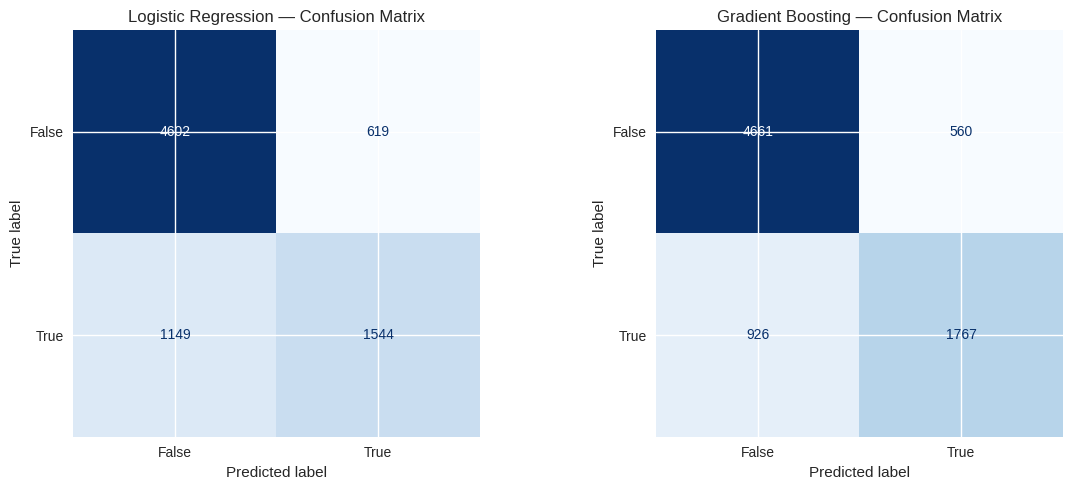

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0], cmap='Blues', colorbar=False,
)
axes[0].set_title('Logistic Regression — Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb, ax=axes[1], cmap='Blues', colorbar=False,
)
axes[1].set_title('Gradient Boosting — Confusion Matrix')

plt.tight_layout()
plt.show()

### Sintesi della Sezione 4

Il **Gradient Boosting** domina su tutte le metriche globali (accuracy 0.812, F1 0.704, ROC AUC 0.882) contro la **Logistic Regression** (accuracy 0.777, F1 0.636, ROC AUC 0.843), con un vantaggio marcato sul recall (+8.3pp).

Il dato rilevante per l'audit di fairness: il recall della Logistic Regression è 0.573, ovvero il modello **non riconosce come positivi il 43% delle persone che effettivamente guadagnano > 50k**. Sono falsi negativi che, in uno scenario applicativo (es. credit scoring), corrisponderebbero a persone meritevoli scartate — è la tipologia di errore la cui distribuzione tra gruppi sensibili costituisce il problema etico di fondo.

Le metriche globali presentate qui sono *cieche al gruppo*. La Sezione 5 le scompone per sottogruppi (race, sex, state) e prepara l'introduzione delle metriche di equità.

## Sezione 5 — Audit algoritmico

Questa sezione applica un **audit algoritmico in 6 fasi**. Le sei fasi sono: (1) Definizione del contesto, (2) Identificazione delle feature sensibili, (3) Analisi dei dati, (4) Valutazione del modello, (5) Mitigazione del bias, (6) Documentazione e trasparenza.

Qui copriamo le **fasi 1-4**: contestualizziamo l'uso del modello, individuiamo gli attributi sensibili e i possibili proxy, sintetizziamo i segnali di bias storico già emersi nell'EDA, e disaggreghiamo le metriche di performance per sottogruppo. Le fasi 5 e 6 sono affrontate rispettivamente nella **Sezione 8** (mitigation) e nella **Sezione 16** (Model Card e limiti).

### Fase 1 — Definizione del contesto

**Obiettivo del modello**: classificare un individuo come `income > 50k USD/anno` sulla base di un profilo socio-economico (occupazione, istruzione, ore lavorate, età, ecc.).

**Scenario applicativo ipotetico**: un sistema di **credit scoring** o di **pricing assicurativo** che usi questa stima come segnale automatizzato. Rientriamo nel caso *dual-use* discusso nell'Introduzione: il dataset nasce statistico-aggregato, l'output del modello diventa operativo su decisioni individuali.

**Gruppi potenzialmente impattati**: minoranze razziali (sottostimate se i pattern storici si riflettono nelle predizioni), donne (gender gap già misurato nell'EDA), abitanti di stati a basso reddito medio (es. Mississippi).

**Riferimento normativo**: l'**AI Act (Reg. UE 2024/1689) art. 10** classifica come *high-risk* gli AI systems usati per credito o assicurazioni — qualità e rappresentatività dei dati di training diventano requisito legale, non solo buona pratica.

### Fase 2 — Identificazione delle feature sensibili

**Sensibili dirette**:
- `SEX` (genere): asse di disparità documentato in tutto il mercato del lavoro.
- `RAC1P` (etnia): asse di disparità storicamente più marcato di quello di genere.

**Variabili a rischio di essere proxy** — correlate alle sensibili anche quando non sono sensibili per definizione:
- `POBP` (place of birth): correla con etnia e percorso migratorio.
- `OCCP` (occupation): storicamente segregata per sesso (caregiving / construction / engineering).
- `NATIVITY` (se presente in versioni estese del task): proxy di etnia/origine.

**`STATE`** è stata esplicitamente rimossa dalle feature del modello nella Sezione 4: la trattiamo come variabile di **stratificazione** per misurare la *context-dependent fairness* CA vs MS, non come predittore.

### Fase 3 — Analisi dei dati

Questa fase è stata anticipata nella **Sezione 3 (EDA quantitativa)**. Riepiloghiamo i risultati essenziali:
- **Bias storico** confermato su tutte e tre le dimensioni (sesso, razza, geografia) con `p < 0.001` su test Chi-quadro.
- **Class imbalance** lieve (~34% di esiti positivi, 66% negativi): rilevante per la scelta di metriche di fairness, non drammatico.
- L'età non è confounder del gender gap (`t-test` non significativo).

### Fase 4 — Valutazione del modello

Passiamo ora dalla descrizione dei dati alla **misura del comportamento dei modelli**: come si comportano i due baseline della Sezione 4 quando le loro predizioni vengono disaggregate per sottogruppi sensibili? Le tabelle che seguono giustificano empiricamente l'introduzione delle metriche di fairness della Sezione 6.

In [19]:
# Recupero attributi sensibili del test set tramite l'indice di X_test su df_features.
sex_test   = df_features.loc[X_test.index, 'SEX'].to_numpy()
race_test  = df_features.loc[X_test.index, 'RAC1P'].to_numpy()
state_test = df_features.loc[X_test.index, 'STATE'].to_numpy()

# Conversione di y_test in array per indicizzazione coerente con i numpy y_pred_*
y_test_arr = y_test.to_numpy()

def metrics_on_mask(y_true, y_pred, mask):
    """Calcola accuracy/precision/recall/F1 su un sottoinsieme booleano."""
    return {
        'accuracy':  accuracy_score(y_true[mask], y_pred[mask]),
        'precision': precision_score(y_true[mask], y_pred[mask], zero_division=0),
        'recall':    recall_score(y_true[mask], y_pred[mask], zero_division=0),
        'f1':        f1_score(y_true[mask], y_pred[mask], zero_division=0),
    }

# Tabella performance per SEX (M=1, F=2) per entrambi i modelli, con gap M-F
rows = []
for model_name, y_pred in [('Logistic Regression', y_pred_lr),
                           ('Gradient Boosting',   y_pred_gb)]:
    m = metrics_on_mask(y_test_arr, y_pred, sex_test == 1)
    f = metrics_on_mask(y_test_arr, y_pred, sex_test == 2)
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        rows.append({
            'model':   model_name,
            'metric':  metric,
            'M':       m[metric],
            'F':       f[metric],
            'gap_M_F': m[metric] - f[metric],
        })

sex_perf = pd.DataFrame(rows).round(3)
print("=== Performance disaggregata per SEX ===")
print(sex_perf.to_string(index=False))

=== Performance disaggregata per SEX ===
              model    metric     M     F  gap_M_F
Logistic Regression  accuracy 0.764 0.789   -0.025
Logistic Regression precision 0.721 0.694    0.027
Logistic Regression    recall 0.686 0.394    0.292
Logistic Regression        f1 0.703 0.503    0.200
  Gradient Boosting  accuracy 0.794 0.832   -0.038
  Gradient Boosting precision 0.765 0.748    0.018
  Gradient Boosting    recall 0.711 0.569    0.142
  Gradient Boosting        f1 0.737 0.646    0.091


In [20]:
# Performance disaggregata per RAC1P sul solo Gradient Boosting
# (su tutti i codici RAC1P presenti nel test set).
rows = []
for code in sorted(pd.unique(race_test)):
    mask = race_test == code
    n = int(mask.sum())
    rows.append({
        'RAC1P':     int(code),
        'n_test':    n,
        'accuracy':  accuracy_score(y_test_arr[mask], y_pred_gb[mask]),
        'precision': precision_score(y_test_arr[mask], y_pred_gb[mask], zero_division=0),
        'recall':    recall_score(y_test_arr[mask], y_pred_gb[mask], zero_division=0),
    })

race_perf = (
    pd.DataFrame(rows)
    .sort_values('accuracy', ascending=False)
    .round(3)
    .reset_index(drop=True)
)
print("=== Performance Gradient Boosting per RAC1P (ordinata per accuracy decrescente) ===")
print(race_perf.to_string(index=False))

=== Performance Gradient Boosting per RAC1P (ordinata per accuracy decrescente) ===
 RAC1P  n_test  accuracy  precision  recall
     5       7     1.000      1.000   1.000
     7      15     1.000      1.000   1.000
     9     189     0.862      0.737   0.636
     2    1368     0.858      0.779   0.401
     3      45     0.844      0.714   0.500
     8     506     0.844      0.733   0.330
     1    5044     0.799      0.750   0.696
     6     740     0.774      0.806   0.731


In [21]:
# Performance disaggregata per STATE (CA vs MS) per entrambi i modelli
rows = []
for model_name, y_pred in [('Logistic Regression', y_pred_lr),
                           ('Gradient Boosting',   y_pred_gb)]:
    for stato in ['CA', 'MS']:
        mask = state_test == stato
        rows.append({
            'model':     model_name,
            'state':     stato,
            'n_test':    int(mask.sum()),
            'accuracy':  accuracy_score(y_test_arr[mask], y_pred[mask]),
            'precision': precision_score(y_test_arr[mask], y_pred[mask], zero_division=0),
            'recall':    recall_score(y_test_arr[mask], y_pred[mask], zero_division=0),
            'f1':        f1_score(y_test_arr[mask], y_pred[mask], zero_division=0),
        })

state_perf = pd.DataFrame(rows).round(3)
print("=== Performance disaggregata per STATE ===")
print(state_perf.to_string(index=False))

=== Performance disaggregata per STATE ===
              model state  n_test  accuracy  precision  recall    f1
Logistic Regression    CA    3957     0.770      0.806   0.579 0.674
Logistic Regression    MS    3957     0.783      0.605   0.565 0.585
  Gradient Boosting    CA    3957     0.820      0.823   0.716 0.766
  Gradient Boosting    MS    3957     0.804      0.660   0.564 0.608


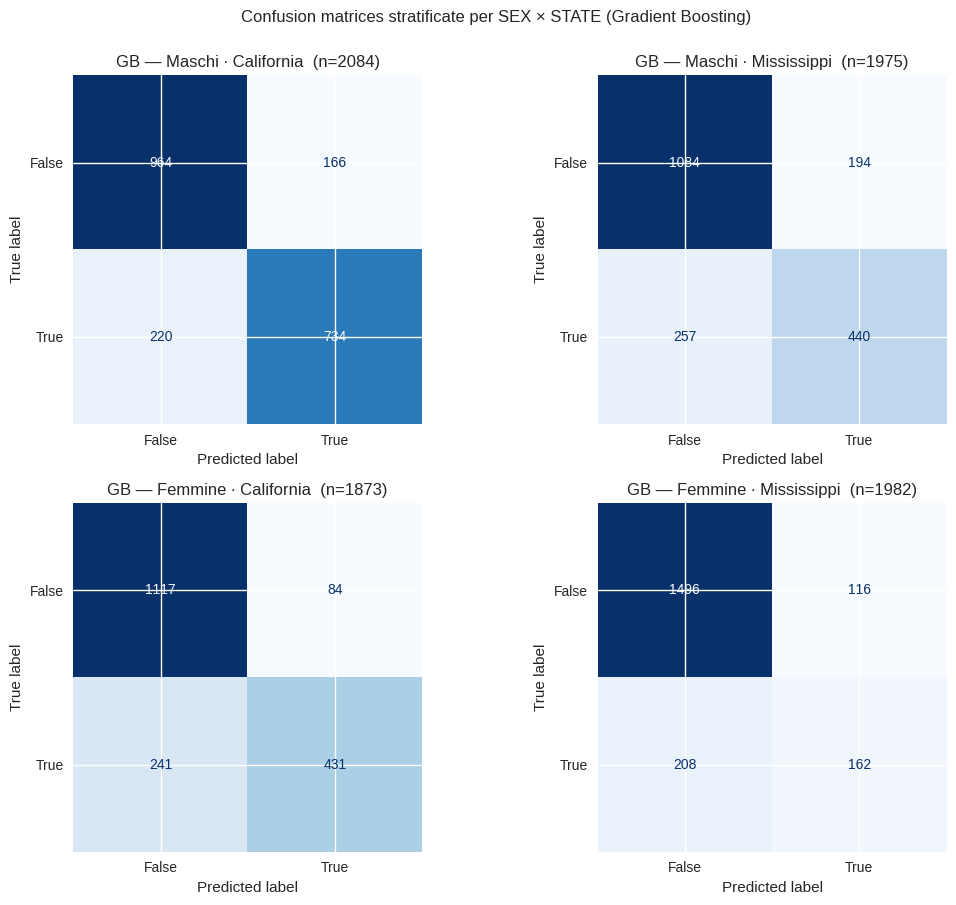

In [22]:
# Confusion matrices stratificate per SEX × STATE sul Gradient Boosting.
# 4 quadranti: (M, CA), (M, MS), (F, CA), (F, MS).
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

quadrants = [
    ((1, 'CA'), 'Maschi · California',   axes[0, 0]),
    ((1, 'MS'), 'Maschi · Mississippi',  axes[0, 1]),
    ((2, 'CA'), 'Femmine · California',  axes[1, 0]),
    ((2, 'MS'), 'Femmine · Mississippi', axes[1, 1]),
]

for (sex_v, state_v), title, ax in quadrants:
    mask = (sex_test == sex_v) & (state_test == state_v)
    ConfusionMatrixDisplay.from_predictions(
        y_test_arr[mask], y_pred_gb[mask],
        ax=ax, cmap='Blues', colorbar=False,
    )
    ax.set_title(f'GB — {title}  (n={int(mask.sum())})')

plt.suptitle('Confusion matrices stratificate per SEX × STATE (Gradient Boosting)', y=1.00)
plt.tight_layout()
plt.show()

### Sintesi della Sezione 5

**Il paradosso accuracy/recall sulle donne**: l'accuracy del Gradient Boosting sulle donne è 0.832 — *più alta* che sugli uomini (0.794). Ma il recall femminile è 0.569 contro 0.711 maschile: il modello **manca il 43% delle donne che effettivamente guadagnano > 50k**, contro il 29% degli uomini. L'accuracy sale perché il modello predice quasi sempre "no" per le donne — *accuracy* e *opportunity* sono fairness diverse, non equivalenti.

**Pattern razziale coerente con quello di genere**: RAC1P=2 (n=1368) ha accuracy GB 0.858 ma recall solo 0.401; RAC1P=6 (Asian, n=740) ha recall 0.731 e accuracy 0.774 — il modello è meno "conservativo" sul gruppo storicamente avvantaggiato. RAC1P=5 e RAC1P=7 mostrano accuracy 1.00 ma con n<20 (non statisticamente affidabile).

**Context-dependent fairness**: il Gradient Boosting ha precision 0.823 in California ma solo 0.660 in Mississippi — lo stesso modello **è sistematicamente meno affidabile in MS**. La fairness non è proprietà del solo modello, ma del modello *nel suo contesto di applicazione*.

La Sezione 6 formalizzerà queste osservazioni con metriche standardizzate (Demographic Parity, Equal Opportunity, Disparate Impact), rendendo esplicito che **non esiste una metrica unica di "fairness"**.

## Sezione 6 — Metriche di equità

Questa sezione formalizza l'audit empirico della Sezione 5 con **6 metriche di equità**. Le sei metriche non sono intercambiabili: rispondono a domande etiche diverse e possono essere divise in tre famiglie.

- **Parità di selezione**: *Demographic Parity* (DP) e *Disparate Impact* (DI) chiedono se i tassi di esito positivo sono uguali tra gruppi, indipendentemente dal "merito".
- **Parità di errore**: *Equal Opportunity* (EOpp) e *Equalized Odds* (EOdds) chiedono se gli errori del modello (FN e FP) sono distribuiti equamente tra gruppi.
- **Parità predittiva**: *Predictive Parity* (PredP) e *Calibration* chiedono se la predizione ha lo stesso significato statistico in ogni gruppo.

L'**impossibility theorem** (Chouldechova 2017; Kleinberg-Mullainathan-Raghavan 2017) dimostra che, salvo casi degeneri, queste tre famiglie non possono essere soddisfatte contemporaneamente. Le definizioni e i riferimenti seguono Barocas-Hardt-Narayanan (fairmlbook.org) e Mehrabi et al. (*ACM Comput. Surv.* 54(6), 2022).

In [23]:
# Funzioni di fairness riusabili nelle Sezioni 8 e 9. Tutte lavorano su numpy.
# Convenzione: y_true e y_pred sono boolean/0-1; A è un array di etichette di gruppo.

def demographic_parity(y_pred, A):
    """DP: P(Ŷ=1 | A=a) per ogni gruppo a. Slide bias 23."""
    return {a: float(y_pred[A == a].mean()) for a in np.unique(A)}

def dp_difference(y_pred, A):
    """max - min di P(Ŷ=1|A=a) tra i gruppi."""
    rates = list(demographic_parity(y_pred, A).values())
    return max(rates) - min(rates)

def equal_opportunity(y_true, y_pred, A):
    """EOpp: TPR = P(Ŷ=1 | Y=1, A=a) per ogni gruppo. Slide bias 24."""
    out = {}
    for a in np.unique(A):
        mask = (A == a) & (y_true == 1)
        out[a] = float(y_pred[mask].mean()) if mask.sum() > 0 else float('nan')
    return out

def eo_difference(y_true, y_pred, A):
    """max - min dei TPR tra i gruppi."""
    tprs = list(equal_opportunity(y_true, y_pred, A).values())
    return max(tprs) - min(tprs)

def equalized_odds(y_true, y_pred, A):
    """EOdds: {gruppo: (TPR, FPR)}. Slide bias 25."""
    out = {}
    for a in np.unique(A):
        mask_a = A == a
        y_a, p_a = y_true[mask_a], y_pred[mask_a]
        pos = (y_a == 1)
        neg = (y_a == 0)
        tpr = float(p_a[pos].mean()) if pos.sum() > 0 else float('nan')
        fpr = float(p_a[neg].mean()) if neg.sum() > 0 else float('nan')
        out[a] = (tpr, fpr)
    return out

def eodds_max_diff(y_true, y_pred, A):
    """Massimo tra |ΔTPR| e |ΔFPR| (worst-case parità di errori)."""
    eo = equalized_odds(y_true, y_pred, A)
    tprs = [v[0] for v in eo.values()]
    fprs = [v[1] for v in eo.values()]
    return max(max(tprs) - min(tprs), max(fprs) - min(fprs))

def disparate_impact(y_pred, A, privileged, unprivileged):
    """DI: P(Ŷ=1|A=unpriv) / P(Ŷ=1|A=priv). Slide bias 26 (regola 80%)."""
    p_priv = y_pred[A == privileged].mean()
    p_unpriv = y_pred[A == unprivileged].mean()
    if p_priv == 0:
        return float('nan')
    return float(p_unpriv / p_priv)

def predictive_parity(y_true, y_pred, A):
    """PredP: PPV = P(Y=1 | Ŷ=1, A=a) — precision per gruppo. Slide bias 27."""
    out = {}
    for a in np.unique(A):
        mask = (A == a) & (y_pred == 1)
        out[a] = float(y_true[mask].mean()) if mask.sum() > 0 else float('nan')
    return out

def pp_difference(y_true, y_pred, A):
    """max - min dei PPV tra i gruppi."""
    ppvs = list(predictive_parity(y_true, y_pred, A).values())
    return max(ppvs) - min(ppvs)

def calibration_by_group(y_true, y_prob, A, n_bins=10):
    """Per ogni gruppo, tupla (mean_predicted_prob, observed_positive_rate). Slide bias 28."""
    out = {}
    y_true_int = np.asarray(y_true).astype(int)
    for a in np.unique(A):
        mask = A == a
        prob_true, prob_pred = calibration_curve(
            y_true_int[mask], y_prob[mask], n_bins=n_bins, strategy='uniform',
        )
        out[a] = (prob_pred, prob_true)
    return out

def di_compliant(di_value, low=0.8, high=1.25):
    """True se Disparate Impact rispetta la regola dell'80% (slide bias 26)."""
    return (di_value >= low) and (di_value <= high)

In [24]:
# Calcolo delle 6 metriche di fairness per SEX sul Gradient Boosting.
# Convenzione: 1 = M (privileged storicamente), 2 = F (unprivileged).
A_sex = sex_test
PRIV_SEX, UNPRIV_SEX = 1, 2

print("=== Gradient Boosting × SEX (1=M, 2=F) ===\n")

# [1] Demographic Parity
dp = demographic_parity(y_pred_gb, A_sex)
dp_d = dp_difference(y_pred_gb, A_sex)
print("[1] Demographic Parity — P(Ŷ=1 | SEX):")
for a, v in dp.items():
    print(f"    SEX={a}: {v:.3f}")
print(f"    DP_difference = {dp_d:.3f}  →  "
      f"{'bias di selezione rilevante' if dp_d > 0.1 else 'differenza contenuta'}\n")

# [2] Equal Opportunity
eopp = equal_opportunity(y_test_arr, y_pred_gb, A_sex)
eopp_d = eo_difference(y_test_arr, y_pred_gb, A_sex)
print("[2] Equal Opportunity — TPR per SEX:")
for a, v in eopp.items():
    print(f"    SEX={a}: {v:.3f}")
print(f"    EOpp_difference = {eopp_d:.3f}  →  "
      f"{'gap di opportunità rilevante' if eopp_d > 0.1 else 'gap contenuto'}\n")

# [3] Equalized Odds
eodds = equalized_odds(y_test_arr, y_pred_gb, A_sex)
eodds_md = eodds_max_diff(y_test_arr, y_pred_gb, A_sex)
print("[3] Equalized Odds — (TPR, FPR) per SEX:")
for a, (tpr, fpr) in eodds.items():
    print(f"    SEX={a}: TPR={tpr:.3f}  FPR={fpr:.3f}")
print(f"    EOdds_max_diff = {eodds_md:.3f}\n")

# [4] Disparate Impact + regola 80%
di = disparate_impact(y_pred_gb, A_sex, PRIV_SEX, UNPRIV_SEX)
ok = di_compliant(di)
print(f"[4] Disparate Impact = P(Ŷ=1|F) / P(Ŷ=1|M) = {di:.3f}")
print(f"    Regola 80% (intervallo [0.8, 1.25]): {'RISPETTATA' if ok else 'VIOLATA'}\n")

# [5] Predictive Parity
pp = predictive_parity(y_test_arr, y_pred_gb, A_sex)
pp_d = pp_difference(y_test_arr, y_pred_gb, A_sex)
print("[5] Predictive Parity — PPV (precision) per SEX:")
for a, v in pp.items():
    print(f"    SEX={a}: {v:.3f}")
print(f"    PredP_difference = {pp_d:.3f}\n")

# [6] Calibration (qualitativa — il plot dettagliato è nella cella 9)
cal = calibration_by_group(y_test_arr, y_prob_gb, A_sex, n_bins=10)
print("[6] Calibration — gap medio |prob_predetta - freq_osservata| per SEX:")
for a, (pp_pred, pp_true) in cal.items():
    gap = float(np.mean(np.abs(pp_pred - pp_true)))
    print(f"    SEX={a}: gap medio = {gap:.3f}")

=== Gradient Boosting × SEX (1=M, 2=F) ===

[1] Demographic Parity — P(Ŷ=1 | SEX):
    SEX=1.0: 0.378
    SEX=2.0: 0.206
    DP_difference = 0.172  →  bias di selezione rilevante

[2] Equal Opportunity — TPR per SEX:
    SEX=1.0: 0.711
    SEX=2.0: 0.569
    EOpp_difference = 0.142  →  gap di opportunità rilevante

[3] Equalized Odds — (TPR, FPR) per SEX:
    SEX=1.0: TPR=0.711  FPR=0.150
    SEX=2.0: TPR=0.569  FPR=0.071
    EOdds_max_diff = 0.142

[4] Disparate Impact = P(Ŷ=1|F) / P(Ŷ=1|M) = 0.544
    Regola 80% (intervallo [0.8, 1.25]): VIOLATA

[5] Predictive Parity — PPV (precision) per SEX:
    SEX=1.0: 0.765
    SEX=2.0: 0.748
    PredP_difference = 0.018

[6] Calibration — gap medio |prob_predetta - freq_osservata| per SEX:
    SEX=1.0: gap medio = 0.022
    SEX=2.0: gap medio = 0.041


In [25]:
# Stesse 6 metriche per SEX sulla Logistic Regression.
A_sex = sex_test
PRIV_SEX, UNPRIV_SEX = 1, 2

print("=== Logistic Regression × SEX (1=M, 2=F) ===\n")

dp = demographic_parity(y_pred_lr, A_sex)
dp_d = dp_difference(y_pred_lr, A_sex)
print("[1] Demographic Parity — P(Ŷ=1 | SEX):")
for a, v in dp.items():
    print(f"    SEX={a}: {v:.3f}")
print(f"    DP_difference = {dp_d:.3f}  →  "
      f"{'bias di selezione rilevante' if dp_d > 0.1 else 'differenza contenuta'}\n")

eopp = equal_opportunity(y_test_arr, y_pred_lr, A_sex)
eopp_d = eo_difference(y_test_arr, y_pred_lr, A_sex)
print("[2] Equal Opportunity — TPR per SEX:")
for a, v in eopp.items():
    print(f"    SEX={a}: {v:.3f}")
print(f"    EOpp_difference = {eopp_d:.3f}  →  "
      f"{'gap di opportunità rilevante' if eopp_d > 0.1 else 'gap contenuto'}\n")

eodds = equalized_odds(y_test_arr, y_pred_lr, A_sex)
eodds_md = eodds_max_diff(y_test_arr, y_pred_lr, A_sex)
print("[3] Equalized Odds — (TPR, FPR) per SEX:")
for a, (tpr, fpr) in eodds.items():
    print(f"    SEX={a}: TPR={tpr:.3f}  FPR={fpr:.3f}")
print(f"    EOdds_max_diff = {eodds_md:.3f}\n")

di = disparate_impact(y_pred_lr, A_sex, PRIV_SEX, UNPRIV_SEX)
ok = di_compliant(di)
print(f"[4] Disparate Impact = P(Ŷ=1|F) / P(Ŷ=1|M) = {di:.3f}")
print(f"    Regola 80% (intervallo [0.8, 1.25]): {'RISPETTATA' if ok else 'VIOLATA'}\n")

pp = predictive_parity(y_test_arr, y_pred_lr, A_sex)
pp_d = pp_difference(y_test_arr, y_pred_lr, A_sex)
print("[5] Predictive Parity — PPV (precision) per SEX:")
for a, v in pp.items():
    print(f"    SEX={a}: {v:.3f}")
print(f"    PredP_difference = {pp_d:.3f}\n")

cal = calibration_by_group(y_test_arr, y_prob_lr, A_sex, n_bins=10)
print("[6] Calibration — gap medio |prob_predetta - freq_osservata| per SEX:")
for a, (pp_pred, pp_true) in cal.items():
    gap = float(np.mean(np.abs(pp_pred - pp_true)))
    print(f"    SEX={a}: gap medio = {gap:.3f}")

=== Logistic Regression × SEX (1=M, 2=F) ===

[1] Demographic Parity — P(Ŷ=1 | SEX):
    SEX=1.0: 0.387
    SEX=2.0: 0.154
    DP_difference = 0.233  →  bias di selezione rilevante

[2] Equal Opportunity — TPR per SEX:
    SEX=1.0: 0.686
    SEX=2.0: 0.394
    EOpp_difference = 0.292  →  gap di opportunità rilevante

[3] Equalized Odds — (TPR, FPR) per SEX:
    SEX=1.0: TPR=0.686  FPR=0.182
    SEX=2.0: TPR=0.394  FPR=0.064
    EOdds_max_diff = 0.292

[4] Disparate Impact = P(Ŷ=1|F) / P(Ŷ=1|M) = 0.397
    Regola 80% (intervallo [0.8, 1.25]): VIOLATA

[5] Predictive Parity — PPV (precision) per SEX:
    SEX=1.0: 0.721
    SEX=2.0: 0.694
    PredP_difference = 0.027

[6] Calibration — gap medio |prob_predetta - freq_osservata| per SEX:
    SEX=1.0: gap medio = 0.018
    SEX=2.0: gap medio = 0.057


In [26]:
# Stesse 6 metriche per STATE sul Gradient Boosting.
# Convenzione: CA = privileged (alto reddito medio), MS = unprivileged.
A_state = state_test
PRIV_STATE, UNPRIV_STATE = 'CA', 'MS'

print("=== Gradient Boosting × STATE (CA vs MS) ===\n")

dp = demographic_parity(y_pred_gb, A_state)
dp_d = dp_difference(y_pred_gb, A_state)
print("[1] Demographic Parity — P(Ŷ=1 | STATE):")
for a, v in dp.items():
    print(f"    STATE={a}: {v:.3f}")
print(f"    DP_difference = {dp_d:.3f}  →  "
      f"{'bias contestuale rilevante' if dp_d > 0.1 else 'differenza contenuta'}\n")

eopp = equal_opportunity(y_test_arr, y_pred_gb, A_state)
eopp_d = eo_difference(y_test_arr, y_pred_gb, A_state)
print("[2] Equal Opportunity — TPR per STATE:")
for a, v in eopp.items():
    print(f"    STATE={a}: {v:.3f}")
print(f"    EOpp_difference = {eopp_d:.3f}\n")

eodds = equalized_odds(y_test_arr, y_pred_gb, A_state)
eodds_md = eodds_max_diff(y_test_arr, y_pred_gb, A_state)
print("[3] Equalized Odds — (TPR, FPR) per STATE:")
for a, (tpr, fpr) in eodds.items():
    print(f"    STATE={a}: TPR={tpr:.3f}  FPR={fpr:.3f}")
print(f"    EOdds_max_diff = {eodds_md:.3f}\n")

di = disparate_impact(y_pred_gb, A_state, PRIV_STATE, UNPRIV_STATE)
ok = di_compliant(di)
print(f"[4] Disparate Impact = P(Ŷ=1|MS) / P(Ŷ=1|CA) = {di:.3f}")
print(f"    Regola 80% (intervallo [0.8, 1.25]): {'RISPETTATA' if ok else 'VIOLATA'}\n")

pp = predictive_parity(y_test_arr, y_pred_gb, A_state)
pp_d = pp_difference(y_test_arr, y_pred_gb, A_state)
print("[5] Predictive Parity — PPV per STATE:")
for a, v in pp.items():
    print(f"    STATE={a}: {v:.3f}")
print(f"    PredP_difference = {pp_d:.3f}\n")

cal = calibration_by_group(y_test_arr, y_prob_gb, A_state, n_bins=10)
print("[6] Calibration — gap medio |prob_predetta - freq_osservata| per STATE:")
for a, (pp_pred, pp_true) in cal.items():
    gap = float(np.mean(np.abs(pp_pred - pp_true)))
    print(f"    STATE={a}: gap medio = {gap:.3f}")

=== Gradient Boosting × STATE (CA vs MS) ===

[1] Demographic Parity — P(Ŷ=1 | STATE):
    STATE=CA: 0.358
    STATE=MS: 0.230
    DP_difference = 0.127  →  bias contestuale rilevante

[2] Equal Opportunity — TPR per STATE:
    STATE=CA: 0.716
    STATE=MS: 0.564
    EOpp_difference = 0.152

[3] Equalized Odds — (TPR, FPR) per STATE:
    STATE=CA: TPR=0.716  FPR=0.107
    STATE=MS: TPR=0.564  FPR=0.107
    EOdds_max_diff = 0.152

[4] Disparate Impact = P(Ŷ=1|MS) / P(Ŷ=1|CA) = 0.645
    Regola 80% (intervallo [0.8, 1.25]): VIOLATA

[5] Predictive Parity — PPV per STATE:
    STATE=CA: 0.823
    STATE=MS: 0.660
    PredP_difference = 0.163

[6] Calibration — gap medio |prob_predetta - freq_osservata| per STATE:
    STATE=CA: gap medio = 0.053
    STATE=MS: gap medio = 0.024


In [27]:
# Tabella riassuntiva: 5 metriche scalari × 2 attributi × 2 modelli.
def collect_scalars(y_true, y_pred, A, priv, unpriv):
    return {
        'DP_diff':         dp_difference(y_pred, A),
        'EOpp_diff':       eo_difference(y_true, y_pred, A),
        'EOdds_maxdiff':   eodds_max_diff(y_true, y_pred, A),
        'DisparateImpact': disparate_impact(y_pred, A, priv, unpriv),
        'PredP_diff':      pp_difference(y_true, y_pred, A),
    }

rows = []
for attr_name, A, priv, unpriv in [
    ('SEX',   sex_test,   1,    2),
    ('STATE', state_test, 'CA', 'MS'),
]:
    m_lr = collect_scalars(y_test_arr, y_pred_lr, A, priv, unpriv)
    m_gb = collect_scalars(y_test_arr, y_pred_gb, A, priv, unpriv)
    for metric in m_lr:
        rows.append({
            'metric':    metric,
            'attribute': attr_name,
            'LR':        m_lr[metric],
            'GB':        m_gb[metric],
        })

fairness_summary = pd.DataFrame(rows).round(3)
print("=== Riepilogo metriche di fairness (LR vs GB, SEX e STATE) ===")
print(fairness_summary.to_string(index=False))

=== Riepilogo metriche di fairness (LR vs GB, SEX e STATE) ===
         metric attribute    LR    GB
        DP_diff       SEX 0.233 0.172
      EOpp_diff       SEX 0.292 0.142
  EOdds_maxdiff       SEX 0.292 0.142
DisparateImpact       SEX 0.397 0.544
     PredP_diff       SEX 0.027 0.018
        DP_diff     STATE 0.043 0.127
      EOpp_diff     STATE 0.014 0.152
  EOdds_maxdiff     STATE 0.039 0.152
DisparateImpact     STATE 0.853 0.645
     PredP_diff     STATE 0.201 0.163


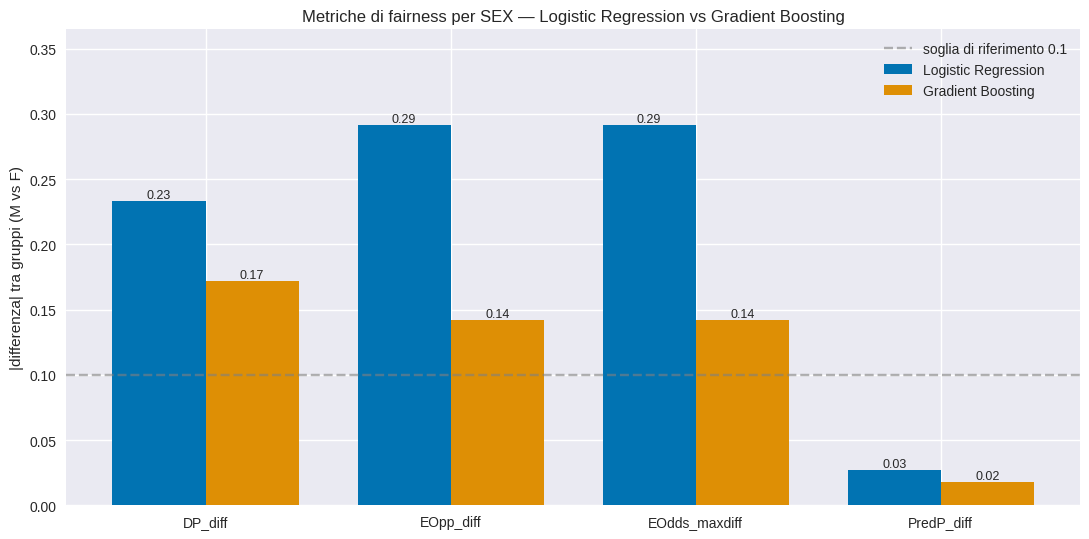

In [28]:
# Plot comparativo: 4 metriche di "difference" per SEX, LR vs GB.
metric_names = ['DP_diff', 'EOpp_diff', 'EOdds_maxdiff', 'PredP_diff']

lr_vals = [
    dp_difference(y_pred_lr, sex_test),
    eo_difference(y_test_arr, y_pred_lr, sex_test),
    eodds_max_diff(y_test_arr, y_pred_lr, sex_test),
    pp_difference(y_test_arr, y_pred_lr, sex_test),
]
gb_vals = [
    dp_difference(y_pred_gb, sex_test),
    eo_difference(y_test_arr, y_pred_gb, sex_test),
    eodds_max_diff(y_test_arr, y_pred_gb, sex_test),
    pp_difference(y_test_arr, y_pred_gb, sex_test),
]

x = np.arange(len(metric_names))
width = 0.38
palette = sns.color_palette('colorblind')

fig, ax = plt.subplots(figsize=(11, 5.5))
bars_lr = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color=palette[0])
bars_gb = ax.bar(x + width/2, gb_vals, width, label='Gradient Boosting', color=palette[1])

# Annotazione valori sopra ogni barra
for bars in (bars_lr, bars_gb):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}',
                    (b.get_x() + b.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9)

# Soglia visiva: 0.1 è un riferimento di letteratura, non uno standard
ax.axhline(0.1, linestyle='--', color='gray', alpha=0.6,
           label='soglia di riferimento 0.1')

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel('|differenza| tra gruppi (M vs F)')
ax.set_title('Metriche di fairness per SEX — Logistic Regression vs Gradient Boosting')
ax.legend()
ax.set_ylim(0, max(max(lr_vals), max(gb_vals)) * 1.25)
plt.tight_layout()
plt.show()

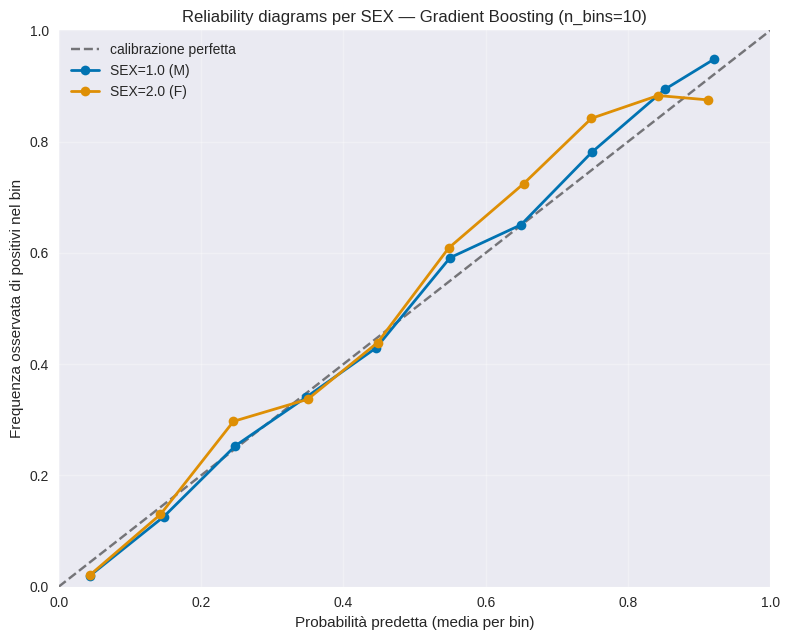

In [29]:
# Reliability diagrams (calibration curves) per SEX sul Gradient Boosting.
cal = calibration_by_group(y_test_arr, y_prob_gb, sex_test, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 6.5))

# Diagonale di calibrazione perfetta
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='calibrazione perfetta')

palette = sns.color_palette('colorblind')
sex_label = {1: 'M', 2: 'F'}
for i, (a, (prob_pred, prob_true)) in enumerate(cal.items()):
    ax.plot(prob_pred, prob_true, 'o-', linewidth=2, markersize=7,
            color=palette[i], label=f'SEX={a} ({sex_label.get(a, a)})')

ax.set_xlabel('Probabilità predetta (media per bin)')
ax.set_ylabel('Frequenza osservata di positivi nel bin')
ax.set_title('Reliability diagrams per SEX — Gradient Boosting (n_bins=10)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sintesi della Sezione 6

**L'impossibility theorem nei dati**. Per SEX, sia il Gradient Boosting (DP_diff = 0.172, EOpp_diff = 0.142, PredP_diff = 0.018) sia la Logistic Regression (DP_diff = 0.233, EOpp_diff = 0.292, PredP_diff = 0.027) violano parità di selezione ed errore ma soddisfano quella predittiva — dimostrazione empirica del risultato di Chouldechova / Kleinberg-Mullainathan-Raghavan: le tre famiglie di fairness sono in conflitto matematico, e quale soddisfare è scelta etica.

**La regola dell'80% (Disparate Impact) è violata sistematicamente**: 0.397 e 0.544 per SEX (LR e GB), 0.853 e 0.645 per STATE — in scenari di credit scoring o pricing assicurativo farebbe scattare contestazione ai sensi dell'AI Act art. 10.

**Il modello "migliore" non è universalmente più equo**. Il GB riduce il gap su SEX (DP_diff da 0.233 a 0.172) ma lo aumenta su STATE (DP_diff da 0.043 a 0.127; EOpp_diff da 0.014 a 0.152). Predictive Parity su STATE: GB giusto all'82% in CA contro 66% in MS.

Le mitigation della Sezione 8 non potranno annullare questo trade-off, ma spostarlo lungo l'asse che si decide di privilegiare.

## Sezione 7 — Spiegabilità con SHAP e LIME

Questa sezione applica l'**interpretabilità post-hoc** (Feature Importance / Correlation Analysis / SHAP / LIME).

**Globale vs locale**. SHAP fornisce sia spiegazioni globali (importanza media delle feature sull'intero dataset) sia locali (contributo di ogni feature a una singola predizione). LIME è puramente locale: approssima il modello black-box con un modello lineare interpretabile nell'intorno del singolo record.

**Perché solo sul Gradient Boosting**. La Logistic Regression è interpretabile *by design*: i coefficienti standardizzati sono già una misura diretta di importanza e direzione. È sul GB — black-box ad alta performance — che serve davvero un'interpretabilità post-hoc.

**Obiettivo dell'audit**. Verificare *se* e *come* le feature correlate ad attributi sensibili (proxy come `OCCP`, `POBP`, `RELP`) entrano nel processo decisionale del modello.

In [30]:
# Estrazione preprocessor (già fit) e classifier dal pipeline GB
preprocessor_fit = gb_pipeline.named_steps['preprocessor']
classifier_gb   = gb_pipeline.named_steps['classifier']

# SHAP scala linearmente con il numero di sample: 500 è sufficiente per
# il summary plot e mantiene il tempo di esecuzione su Colab sotto controllo.
N_SHAP_SAMPLE = 500
X_test_sample = X_test.sample(n=N_SHAP_SAMPLE, random_state=SEED)
X_test_sample_transformed = preprocessor_fit.transform(X_test_sample)

print(f"X_test_sample shape:             {X_test_sample.shape}")
print(f"X_test_sample_transformed shape: {X_test_sample_transformed.shape}")
print(f"Feature names ({len(numeric_features)}):              {numeric_features}")

X_test_sample shape:             (500, 10)
X_test_sample_transformed shape: (500, 10)
Feature names (10):              ['AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP', 'SEX', 'RAC1P']


In [31]:
# TreeExplainer è ottimizzato per modelli tree-based: ~ordini di grandezza
# più veloce di KernelExplainer su GBM/RandomForest.
explainer = shap.TreeExplainer(classifier_gb)

# Per binary classification, SHAP recente restituisce un singolo array 2D
# (margin/log-odds della classe positiva); versioni più vecchie ritornano
# una lista [class_0, class_1] — gestiamo entrambi i casi.
raw_shap = explainer.shap_values(X_test_sample_transformed)
if isinstance(raw_shap, list):
    shap_values = raw_shap[1]
else:
    shap_values = raw_shap

# expected_value: scalar o lista a seconda della versione SHAP
ev = explainer.expected_value
if hasattr(ev, '__len__') and not isinstance(ev, str):
    expected_value = float(ev[1]) if len(ev) == 2 else float(ev[0])
else:
    expected_value = float(ev)

print(f"shap_values shape:  {shap_values.shape}")
print(f"expected_value:     {expected_value:.4f}")

shap_values shape:  (500, 10)
expected_value:     -1.0685


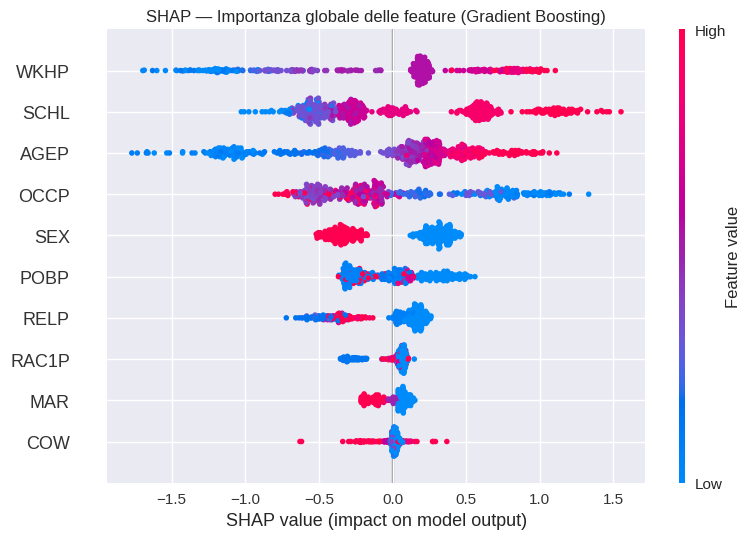

In [32]:
# Summary plot SHAP: distribuzione dei valori SHAP per ogni feature
# (colore = valore della feature, posizione = contributo alla predizione).
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_sample_transformed,
    feature_names=numeric_features,
    show=False,
)
plt.title('SHAP — Importanza globale delle feature (Gradient Boosting)')
plt.tight_layout()
plt.show()

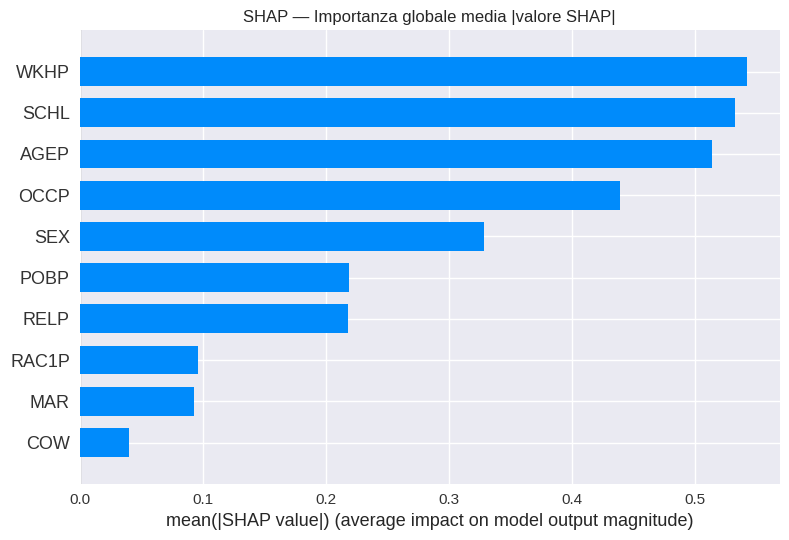

In [33]:
# Bar plot SHAP: importanza media |valore SHAP| per feature.
# Più leggibile del summary scatter quando interessa solo l'ordine.
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_sample_transformed,
    feature_names=numeric_features,
    plot_type='bar',
    show=False,
)
plt.title('SHAP — Importanza globale media |valore SHAP|')
plt.tight_layout()
plt.show()

In [34]:
# Mapping degli indici del sample alle posizioni in X_test, così possiamo
# proiettare y_pred / y_prob / attributi sensibili sul sottoinsieme SHAP.
sample_positions = X_test.index.get_indexer(X_test_sample.index)

y_true_sample = y_test_arr[sample_positions]
y_pred_sample = y_pred_gb[sample_positions]
y_prob_sample = y_prob_gb[sample_positions]
sex_sample    = sex_test[sample_positions]
race_sample   = race_test[sample_positions]
state_sample  = state_test[sample_positions]

# Caso A — TP confidente: predizione corretta positiva con probabilità alta
mask_A = (y_true_sample == 1) & (y_pred_sample == 1) & (y_prob_sample > 0.8)
idx_A = int(np.where(mask_A)[0][0])

# Caso B — TN confidente: predizione corretta negativa con probabilità bassa
mask_B = (y_true_sample == 0) & (y_pred_sample == 0) & (y_prob_sample < 0.2)
idx_B = int(np.where(mask_B)[0][0])

# Caso C — FN incerto: falso negativo con probabilità in zona indecisa
mask_C = (y_true_sample == 1) & (y_pred_sample == 0) & (y_prob_sample > 0.3) & (y_prob_sample < 0.5)
matches = np.where(mask_C)[0]
if len(matches) == 0:
    # Fallback: qualsiasi predizione al confine 0.4-0.6
    mask_C = (y_prob_sample > 0.4) & (y_prob_sample < 0.6)
    matches = np.where(mask_C)[0]
idx_C = int(matches[0])

cases_idx   = [idx_A, idx_B, idx_C]
case_labels = ['Caso A — TP confidente',
               'Caso B — TN confidente',
               'Caso C — FN incerto']

print("=== Casi selezionati per analisi locale ===\n")
for label, idx in zip(case_labels, cases_idx):
    print(f"{label}")
    print(f"  sample_idx   = {idx}")
    print(f"  original_idx = {X_test_sample.index[idx]}")
    print(f"  y_true       = {int(y_true_sample[idx])}")
    print(f"  y_pred       = {int(y_pred_sample[idx])}")
    print(f"  y_prob       = {y_prob_sample[idx]:.3f}")
    print(f"  SEX          = {int(sex_sample[idx])}")
    print(f"  RAC1P        = {int(race_sample[idx])}")
    print(f"  STATE        = {state_sample[idx]}")
    print()

=== Casi selezionati per analisi locale ===

Caso A — TP confidente
  sample_idx   = 11
  original_idx = 6281
  y_true       = 1
  y_pred       = 1
  y_prob       = 0.829
  SEX          = 1
  RAC1P        = 1
  STATE        = CA

Caso B — TN confidente
  sample_idx   = 0
  original_idx = 21593
  y_true       = 0
  y_pred       = 0
  y_prob       = 0.070
  SEX          = 2
  RAC1P        = 1
  STATE        = MS

Caso C — FN incerto
  sample_idx   = 15
  original_idx = 18963
  y_true       = 1
  y_pred       = 0
  y_prob       = 0.465
  SEX          = 1
  RAC1P        = 1
  STATE        = MS



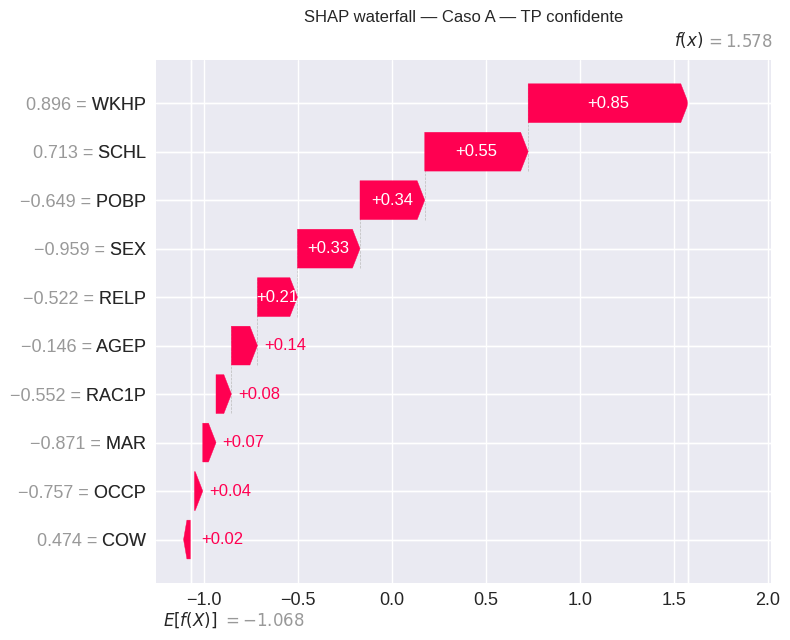

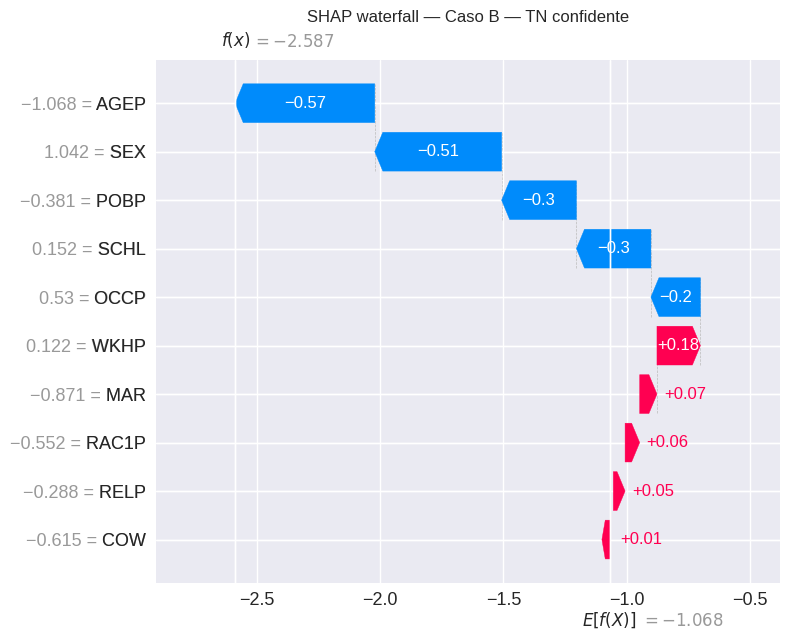

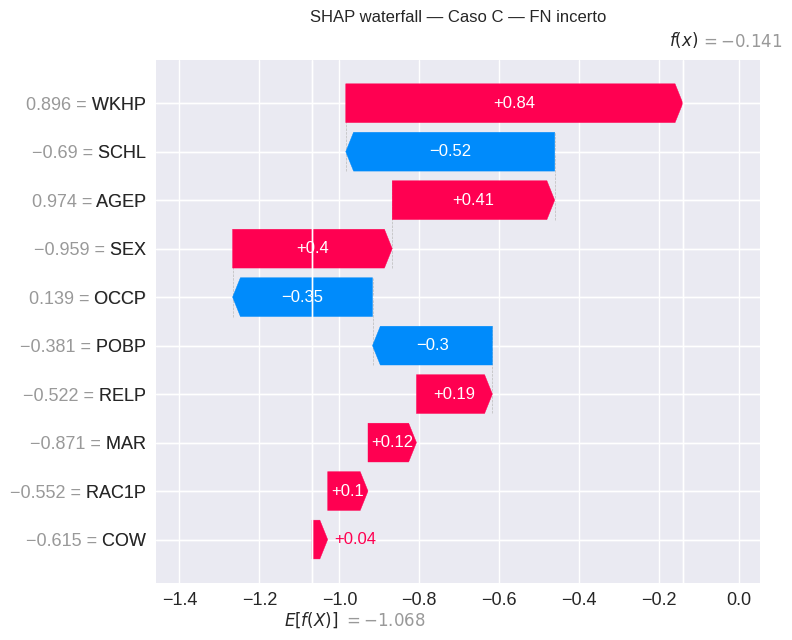

In [35]:
# Waterfall plot SHAP per ciascuno dei 3 casi: mostra come ogni feature
# contribuisce (positivamente o negativamente) a spostare la predizione
# dalla base (expected_value) al risultato finale.
for label, idx in zip(case_labels, cases_idx):
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=expected_value,
        data=X_test_sample_transformed[idx],
        feature_names=numeric_features,
    )
    plt.figure()
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'SHAP waterfall — {label}')
    plt.tight_layout()
    plt.show()

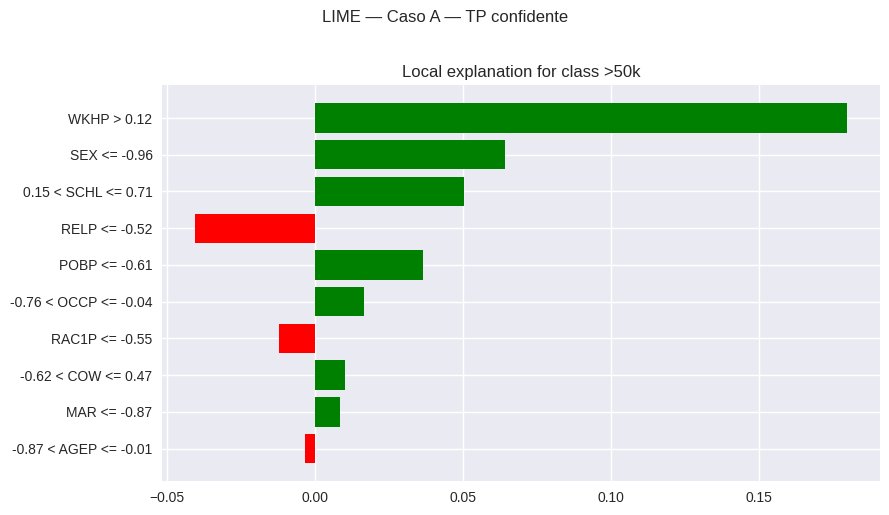

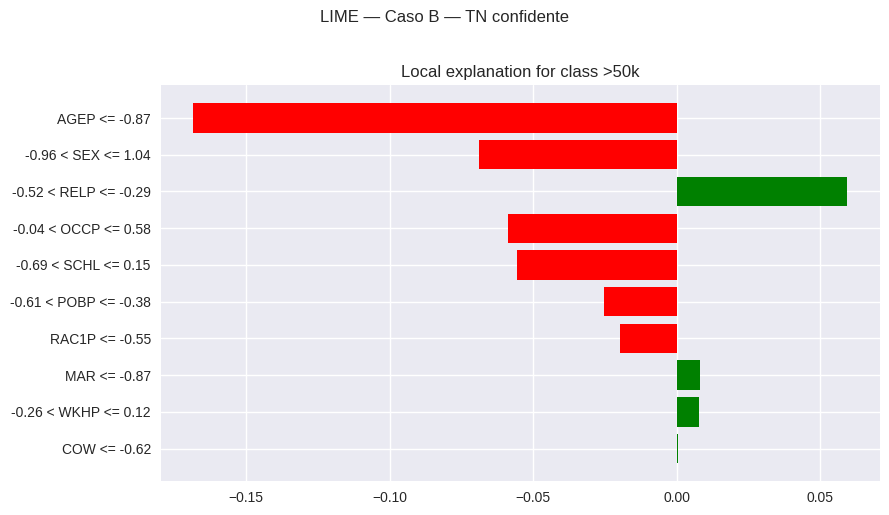

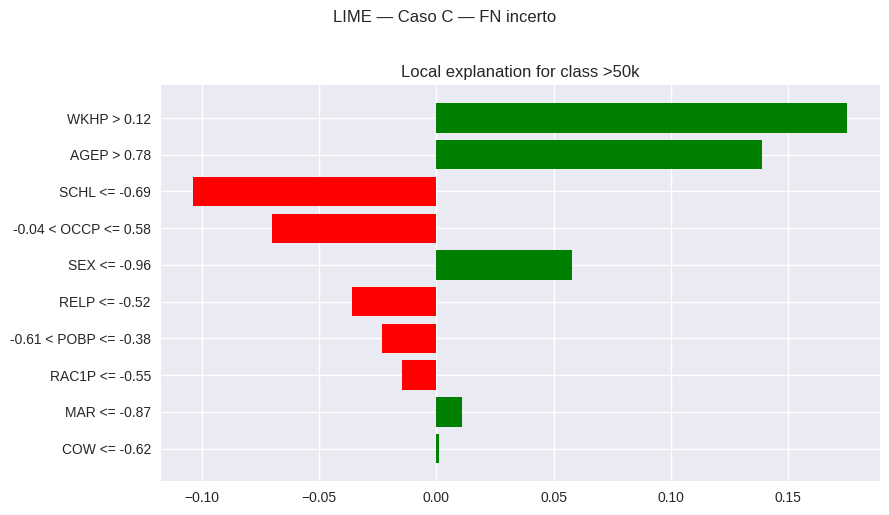

In [36]:
# LIME lavora nello stesso spazio del classificatore (post-preprocessing):
# training_data e data_row devono essere già trasformati, e il predict_fn è
# quello del classifier diretto, non del pipeline.
X_train_transformed = preprocessor_fit.transform(X_train)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=numeric_features,
    class_names=['<=50k', '>50k'],
    discretize_continuous=True,
    random_state=SEED,
)

for label, idx in zip(case_labels, cases_idx):
    exp = lime_explainer.explain_instance(
        data_row=X_test_sample_transformed[idx],
        predict_fn=classifier_gb.predict_proba,
        num_features=10,
    )
    fig = exp.as_pyplot_figure()
    fig.suptitle(f'LIME — {label}', y=1.02)
    plt.tight_layout()
    plt.show()

### Sintesi della Sezione 7

**Importanza globale**. Top 5 feature per |SHAP value| medio: WKHP, SCHL, AGEP, OCCP, **SEX**. WKHP/SCHL/AGEP sono predittori legittimi; OCCP funge da proxy storicamente segregato; SEX entra direttamente in 5°. Nel summary plot, per SEX i punti femminili hanno SHAP value sistematicamente negativo e i maschili positivo — regola applicata in ogni decisione.

**Spiegazioni locali**. Caso A (M, white, CA, TP, prob 0.83): SEX **+0.33**, dopo WKHP (+0.85), SCHL (+0.55), POBP (+0.34). Caso B (F, white, MS, TN, prob 0.07): SEX **-0.51** — produce il DP_difference di 0.172. Caso C, errore stereotipico (M, white, MS, FN, prob 0.47): SCHL (-0.52) e OCCP (-0.35) spingono al negativo nonostante WKHP (+0.84), AGEP (+0.41), SEX (+0.40); il modello legge stereotipi statistici, non individui.

**SHAP vs LIME**: accordo qualitativo alto sui 3 casi, stessi contributori con segno coerente; LIME frammenta su soglie discrete (es. "WKHP > 0.12"), senza divergenze significative.

Il bias usa SEX direttamente e OCCP come proxy. La Sezione 8 sceglierà il punto di intervento (pre / in / post) in base a questa struttura.

## Sezione 8 — Mitigation del bias

Questa sezione applica tre tecniche di **mitigation del bias**, una per ciascuna delle tre categorie canoniche:

- **Pre-processing** — *Reweighing*: modifica i pesi dei record nel training set prima dell'apprendimento.
- **In-processing** — *Exponentiated Gradient* con vincolo Equal Opportunity (famiglia *Fairness Constraints*): integra la fairness come vincolo nel problema di ottimizzazione.
- **Post-processing** — *ThresholdOptimizer* con `equalized_odds` (equivalente di *Equalized Odds Post-processing*): modifica solo le soglie di decisione sull'output del modello già addestrato.

L'attributo sensibile target è **SEX** (1=M privileged, 2=F unprivileged); le mitigation su STATE sono lasciate alla discussione della Sezione 9 per non appesantire. **Aspettativa coerente con l'impossibility theorem**: ogni tecnica migliorerà alcune metriche e ne lascerà invariate (o peggiorerà) altre — non esiste un Pareto-dominante.

### 8.1 Pre-processing — Reweighing

**Formula**:

$$ w(s, y) = \frac{P(s) \cdot P(y)}{P(s, y)} $$

**Logica**: pesi maggiori a `(gruppo svantaggiato, esito positivo)` e `(gruppo avvantaggiato, esito negativo)` — cioè alle combinazioni *sotto-rappresentate* rispetto a quanto ci si aspetterebbe in caso di indipendenza fra `s` e `y`; pesi minori alle combinazioni "tipiche" del bias storico. Il modello, fittato con questi `sample_weight`, vede un mondo riequilibrato.

**Implementazione manuale** (no AIF360, troppo pesante per Colab): calcoliamo i 4 pesi e li passiamo via `sample_weight` ai pipeline `LR` e `GB`.

In [37]:
# sex_train allineato con X_train (recuperato via indice da df_features)
sex_train   = df_features.loc[X_train.index, 'SEX'].to_numpy()
y_train_arr = y_train.to_numpy().astype(int)

# Marginali e congiunta su training set
P_s  = {s: float((sex_train == s).mean())     for s in [1, 2]}
P_y  = {y: float((y_train_arr == y).mean())   for y in [0, 1]}
P_sy = {}
weights = {}
for s in [1, 2]:
    for y in [0, 1]:
        mask = (sex_train == s) & (y_train_arr == y)
        P_sy[(s, y)] = float(mask.mean())
        weights[(s, y)] = (P_s[s] * P_y[y]) / P_sy[(s, y)] if P_sy[(s, y)] > 0 else 1.0

print("=== Pesi Reweighing w(s,y) = P(s)·P(y) / P(s,y) ===")
print(f"{'SEX':>4s} {'y':>2s} {'P(s)':>6s} {'P(y)':>6s} {'P(s,y)':>7s} {'w':>6s}")
for (s, y), w in weights.items():
    print(f"{s:>4d} {y:>2d} {P_s[s]:>6.3f} {P_y[y]:>6.3f} {P_sy[(s,y)]:>7.3f} {w:>6.3f}")

# Vettore sample_weight allineato a X_train
sample_weight = np.array([weights[(s, y)] for s, y in zip(sex_train, y_train_arr)])

# Pipelines freschi (ColumnTransformer nuovo per non mutare le baseline)
lr_rw_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features)],
        remainder='drop',
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=SEED)),
])
gb_rw_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[('num', StandardScaler(), numeric_features)],
        remainder='drop',
    )),
    ('classifier', GradientBoostingClassifier(random_state=SEED)),
])

# Fit con sample_weight: la sintassi sklearn pipeline richiede prefisso "classifier__"
lr_rw_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weight)
gb_rw_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weight)

# Predizioni reweighed
y_pred_lr_rw = lr_rw_pipeline.predict(X_test)
y_prob_lr_rw = lr_rw_pipeline.predict_proba(X_test)[:, 1]
y_pred_gb_rw = gb_rw_pipeline.predict(X_test)
y_prob_gb_rw = gb_rw_pipeline.predict_proba(X_test)[:, 1]

print("\nReweighing: pipelines LR e GB fittati con sample_weight.")

=== Pesi Reweighing w(s,y) = P(s)·P(y) / P(s,y) ===
 SEX  y   P(s)   P(y)  P(s,y)      w
   1  0  0.521  0.660   0.306  1.123
   1  1  0.521  0.340   0.215  0.825
   2  0  0.479  0.660   0.354  0.894
   2  1  0.479  0.340   0.125  1.300

Reweighing: pipelines LR e GB fittati con sample_weight.


### 8.2 In-processing — Exponentiated Gradient

**Logica**: la classe `fairlearn.reductions.ExponentiatedGradient` riformula l'apprendimento come **problema di ottimizzazione vincolata**: minimizza la loss soggetta a un vincolo di fairness (qui `TruePositiveRateParity`, equivalente di *Equal Opportunity*). Internamente itera su un gioco di Lagrange tra il classificatore e un "avversario" che penalizza la violazione del vincolo.

**Output**: un classificatore *fairness-aware* che approssima un punto sul fronte di Pareto accuracy ↔ fairness. Il parametro `eps` controlla la tolleranza al vincolo: valori più piccoli = vincolo più stretto, ma rischio di accuracy degradata.

**Limite operativo**: ExpGrad non espone `predict_proba` direttamente — le metriche basate su probabilità (es. calibration) non saranno calcolabili.

In [38]:
# ExponentiatedGradient lavora su array già preprocessati (non accetta pipeline).
# Riutilizziamo preprocessor_fit dal pipeline GB della Sezione 4 (già fit-applicato).
X_train_transformed_eg = preprocessor_fit.transform(X_train)
X_test_transformed_eg  = preprocessor_fit.transform(X_test)

# eps piccolo = vincolo stretto. 0.01 è un buon compromesso su dataset di questa scala.
mitigator_eg = ExponentiatedGradient(
    estimator=GradientBoostingClassifier(random_state=SEED),
    constraints=TruePositiveRateParity(),
    eps=0.01,
)
mitigator_eg.fit(
    X_train_transformed_eg,
    y_train_arr,
    sensitive_features=sex_train,
)

# ExpGrad non espone predict_proba: solo predizioni hard
y_pred_gb_eg = mitigator_eg.predict(X_test_transformed_eg)

print("Exponentiated Gradient: training completato.")
print(f"y_pred_gb_eg shape: {y_pred_gb_eg.shape}, dtype: {y_pred_gb_eg.dtype}")

Exponentiated Gradient: training completato.
y_pred_gb_eg shape: (7914,), dtype: int64


### 8.3 Post-processing — ThresholdOptimizer

**Logica**: dato un modello già addestrato (`prefit=True`), `ThresholdOptimizer` cerca **soglie di decisione diverse per gruppo** sull'output del modello per soddisfare un vincolo di fairness (qui `equalized_odds`). Modifica solo l'output, non il modello sottostante.

**Vantaggio**: modulare e poco invasivo — nessun re-training, applicabile a qualsiasi classificatore già in produzione.

**Svantaggio**: per predire ha bisogno dell'attributo sensibile *a runtime*. In molti contesti operativi (es. credit scoring), accettare di applicare soglie diverse per genere o etnia è giuridicamente problematico o socialmente controverso, anche quando lo scopo è correggere il bias.

In [39]:
# Wrappa il gb_pipeline già fit (Sezione 4). prefit=True dice a fairlearn di
# non rieffettuare il training; .fit() qui serve solo a trovare le soglie ottimali.
mitigator_to = ThresholdOptimizer(
    estimator=gb_pipeline,
    constraints='equalized_odds',
    objective='accuracy_score',
    prefit=True,
    predict_method='predict_proba',
)
mitigator_to.fit(X_train, y_train, sensitive_features=sex_train)

# Predict richiede sensitive_features anche al momento della predizione
y_pred_gb_to = mitigator_to.predict(X_test, sensitive_features=sex_test)

print("ThresholdOptimizer: soglie ottimali trovate per ciascun gruppo SEX.")
print(f"y_pred_gb_to shape: {y_pred_gb_to.shape}, dtype: {y_pred_gb_to.dtype}")

ThresholdOptimizer: soglie ottimali trovate per ciascun gruppo SEX.
y_pred_gb_to shape: (7914,), dtype: int64


In [40]:
# Valutazione comparativa: GB baseline vs 3 mitigation, attributo SEX.
def fairness_metrics_sex(y_true, y_pred, A, priv=1, unpriv=2):
    return {
        'accuracy':       accuracy_score(y_true, y_pred),
        'DP_diff':        dp_difference(y_pred, A),
        'EOpp_diff':      eo_difference(y_true, y_pred, A),
        'EOdds_maxdiff':  eodds_max_diff(y_true, y_pred, A),
        'DI':             disparate_impact(y_pred, A, priv, unpriv),
        'PredP_diff':     pp_difference(y_true, y_pred, A),
    }

results_mitigation = {
    'baseline':     fairness_metrics_sex(y_test_arr, y_pred_gb,    sex_test),
    'Reweighing':   fairness_metrics_sex(y_test_arr, y_pred_gb_rw, sex_test),
    'ExpGrad':      fairness_metrics_sex(y_test_arr, y_pred_gb_eg, sex_test),
    'ThresholdOpt': fairness_metrics_sex(y_test_arr, y_pred_gb_to, sex_test),
}

mitigation_table = pd.DataFrame(results_mitigation).round(3)
print("=== Confronto baseline vs 3 mitigation (Gradient Boosting × SEX) ===")
print(mitigation_table)

=== Confronto baseline vs 3 mitigation (Gradient Boosting × SEX) ===
               baseline  Reweighing  ExpGrad  ThresholdOpt
accuracy          0.812       0.805    0.811         0.797
DP_diff           0.172       0.056    0.126         0.093
EOpp_diff         0.142       0.050    0.069         0.052
EOdds_maxdiff     0.142       0.050    0.069         0.052
DI                0.544       0.827    0.649         0.741
PredP_diff        0.018       0.106    0.062         0.133


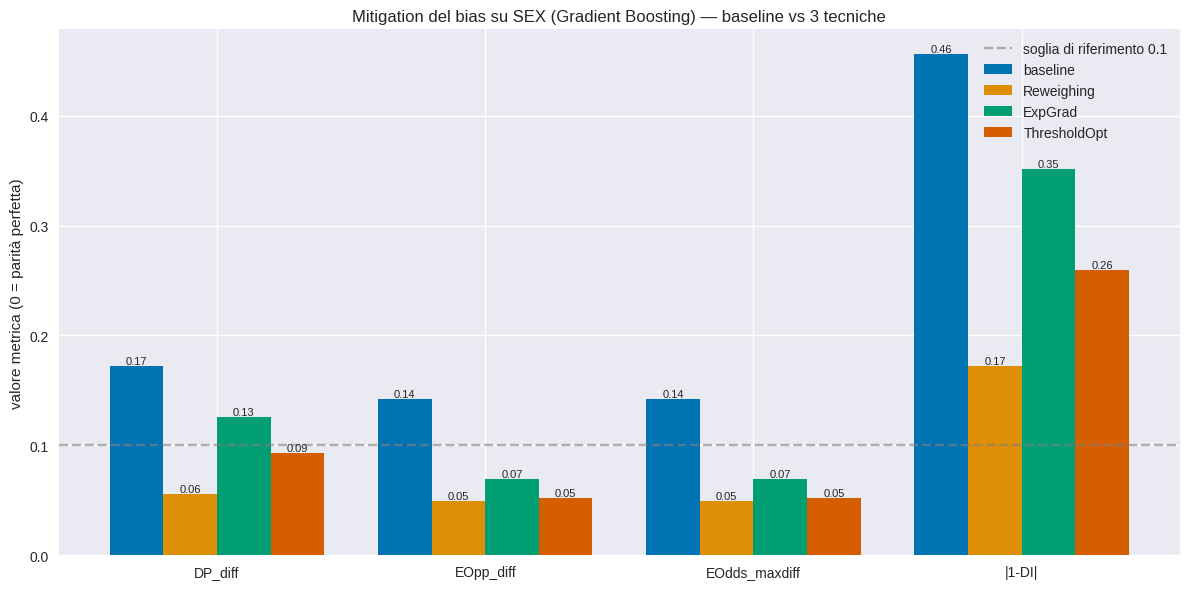

In [41]:
# Bar plot raggruppato: 4 modelli × 4 metriche di fairness.
# |1 - DI| rende il Disparate Impact direttamente confrontabile con le altre
# (0 = perfetta parità, valori grandi = bias).
metrics_to_plot = ['DP_diff', 'EOpp_diff', 'EOdds_maxdiff', '|1-DI|']
models = ['baseline', 'Reweighing', 'ExpGrad', 'ThresholdOpt']
palette = sns.color_palette('colorblind', n_colors=4)

def values_for(model):
    r = results_mitigation[model]
    return [r['DP_diff'], r['EOpp_diff'], r['EOdds_maxdiff'], abs(1 - r['DI'])]

x = np.arange(len(metrics_to_plot))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 6))
for i, m in enumerate(models):
    vals = values_for(m)
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=m, color=palette[i])
    for b in bars:
        h = b.get_height()
        if pd.notna(h):
            ax.annotate(f'{h:.2f}',
                        (b.get_x() + b.get_width() / 2, h),
                        ha='center', va='bottom', fontsize=8)

ax.axhline(0.1, linestyle='--', color='gray', alpha=0.6,
           label='soglia di riferimento 0.1')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('valore metrica (0 = parità perfetta)')
ax.set_title('Mitigation del bias su SEX (Gradient Boosting) — baseline vs 3 tecniche')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Sintesi della Sezione 8

**Il Reweighing è la tecnica con il miglior rapporto qualità/prezzo**. Riduce DP_difference da 0.172 a 0.056 (-67%), EOpp_difference da 0.142 a 0.050 (-65%), e **porta il Disparate Impact a 0.827, dentro la regola dell'80%** che il baseline violava (0.544). Costo: 0.7 pp di accuracy. Implementazione: 4 pesi calcolati manualmente.

**L'impossibility theorem si manifesta empiricamente sulla Predictive Parity**. Il baseline è calibrato (PredP_diff = 0.018); le tre mitigation la rompono: PredP_diff sale a 0.106 (Reweighing), 0.062 (ExpGrad), 0.133 (ThresholdOpt). Ridurre parità di selezione (DP, DI) o errore (EOpp, EOdds) sacrifica quella predittiva — risultato di Chouldechova / Kleinberg-Mullainathan-Raghavan.

**ExpGrad e ThresholdOptimizer**: risultati intermedi. ExpGrad è più costoso (~60s vs <1s del Reweighing) con guadagno fairness minore. ThresholdOptimizer ha il costo di accuracy più alto (-1.5pp) e la peggior PredP_diff (0.133); paga in modularità (no re-training) ma richiede l'attributo sensibile a runtime, spesso giuridicamente controverso.

Ridurre il bias mantenendo accuracy è possibile, ma nessuna scelta è "neutra": ogni tecnica privilegia una concezione di fairness. La Sezione 9 quantifica il trade-off accuracy ↔ fairness.

## Sezione 9 — Trade-off accuracy ↔ fairness

Il trade-off accuracy ↔ fairness è la rappresentazione standard della tensione tra performance predittiva ed equità. Punto cruciale: **non esiste un "fronte di Pareto" universale**. Il fronte dipende dalla definizione di fairness scelta come asse Y (DP, EOpp, DI, ecc.) e i 4 modelli si posizionano diversamente a seconda di quale metrica si privilegia.

**Riferimento normativo**: l'**AI Act (Reg. UE 2024/1689) art. 10** impone che i dati di training di sistemi *high-risk* rispettino criteri di qualità e rappresentatività, ma **non specifica quale metrica di fairness ottimizzare**. La scelta è etica, non tecnica.

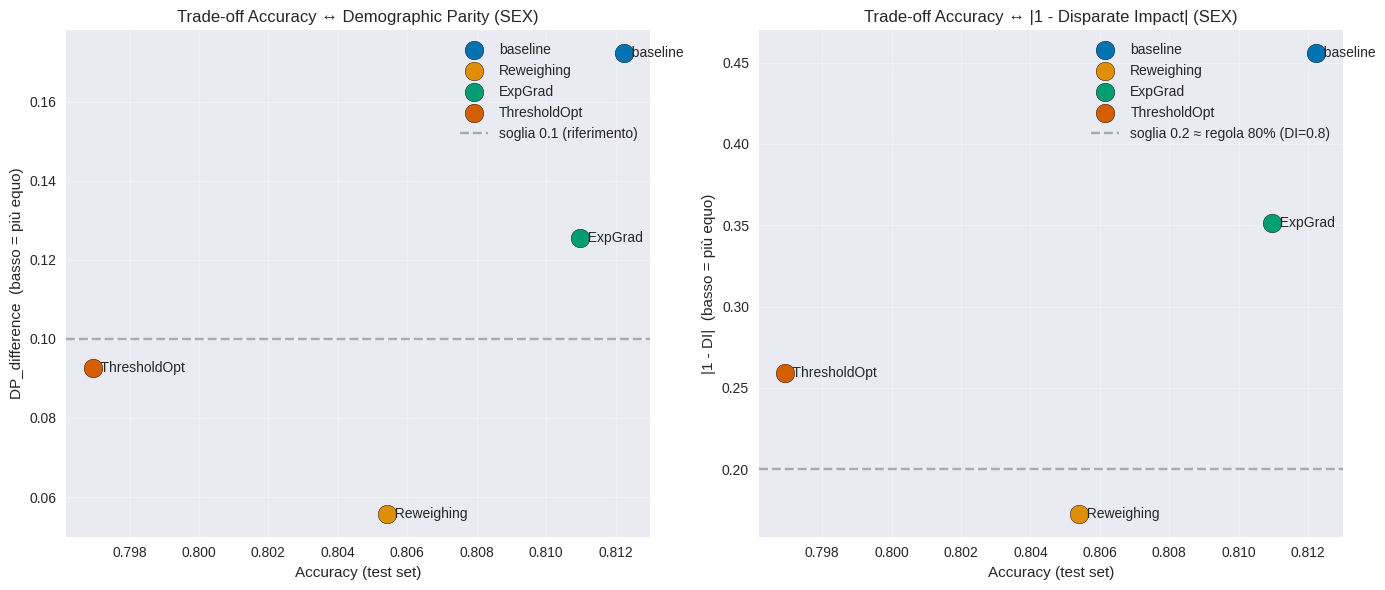

In [42]:
# Calcolo accuracy + 2 metriche di fairness per i 4 modelli GB
PRIV, UNPRIV = 1, 2  # SEX: 1=M priv, 2=F unpriv

predictions = {
    'baseline':     y_pred_gb,
    'Reweighing':   y_pred_gb_rw,
    'ExpGrad':      y_pred_gb_eg,
    'ThresholdOpt': y_pred_gb_to,
}

acc_vals    = {}
dp_vals     = {}
di_dev_vals = {}  # |1 - DI|

for name, y_pred in predictions.items():
    acc_vals[name]    = accuracy_score(y_test_arr, y_pred)
    dp_vals[name]     = dp_difference(y_pred, sex_test)
    di_dev_vals[name] = abs(1 - disparate_impact(y_pred, sex_test, PRIV, UNPRIV))

palette = sns.color_palette('colorblind', n_colors=4)
colors  = {name: palette[i] for i, name in enumerate(predictions)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === Subplot SINISTRO: accuracy vs DP_difference ===
ax = axes[0]
for name in predictions:
    ax.scatter(acc_vals[name], dp_vals[name],
               s=180, color=colors[name], edgecolor='black', zorder=3, label=name)
    ax.annotate(f'  {name}', (acc_vals[name], dp_vals[name]),
                fontsize=10, va='center')
ax.axhline(0.1, linestyle='--', color='gray', alpha=0.6,
           label='soglia 0.1 (riferimento)')
ax.set_xlabel('Accuracy (test set)')
ax.set_ylabel('DP_difference  (basso = più equo)')
ax.set_title('Trade-off Accuracy ↔ Demographic Parity (SEX)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# === Subplot DESTRO: accuracy vs |1 - DI| ===
ax = axes[1]
for name in predictions:
    ax.scatter(acc_vals[name], di_dev_vals[name],
               s=180, color=colors[name], edgecolor='black', zorder=3, label=name)
    ax.annotate(f'  {name}', (acc_vals[name], di_dev_vals[name]),
                fontsize=10, va='center')
ax.axhline(0.2, linestyle='--', color='gray', alpha=0.6,
           label='soglia 0.2 ≈ regola 80% (DI=0.8)')
ax.set_xlabel('Accuracy (test set)')
ax.set_ylabel('|1 - DI|  (basso = più equo)')
ax.set_title('Trade-off Accuracy ↔ |1 - Disparate Impact| (SEX)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Sintesi della Sezione 9

La geometria del fronte di Pareto **dipende dalla metrica di fairness scelta come asse Y**.

**Su accuracy ↔ DP_difference**: il baseline domina su accuracy (0.812) ma con DP_diff = 0.172; il Reweighing è Pareto-ottimo (DP_diff = 0.056, accuracy = 0.805). ExpGrad mantiene accuracy quasi-baseline (0.811) ma fairness lontana dalla soglia (DP_diff = 0.126); ThresholdOpt scende a 0.797 senza guadagnare in fairness.

**Su accuracy ↔ |1 - DI|**: solo Reweighing entra sotto 0.2, dentro la regola dell'80%. Le altre due restano fuori dalla "compliance" anche al costo dell'accuracy.

**Avvertenza**. Il Reweighing non è "universalmente migliore": lo è *se* si misura la fairness con DP o DI. Su EOpp_diff e EOdds_maxdiff sono ExpGrad e ThresholdOptimizer a battere il Reweighing. Il fronte di Pareto cambia con l'asse Y — la scelta della metrica è etica, la tecnica viene dopo.

La Parte B affronta la privacy: anche lì un trade-off strutturale (privacy ↔ utility); fairness ↔ accuracy e privacy ↔ utility si combineranno nel **trilemma** della Sezione 14.

## Parte B — Protezione della privacy

## Sezione 10 — Identificatori e quasi-identificatori

Nella **Parte A** abbiamo affrontato il bias come una proprietà del *modello* e dei suoi output. Nella **Parte B** spostiamo l'attenzione a un livello più basso: la **protezione della privacy** è una proprietà dei *dati* stessi. Prima ancora che un modello venga addestrato, i dati pongono il problema di proteggere l'identità delle persone rappresentate.

Questa Sezione 10 introduce la distinzione concettuale fondamentale: **identificatore diretto vs quasi-identificatore**. Un identificatore diretto identifica univocamente una persona (nome, codice fiscale, email); un quasi-identificatore non identifica da solo, ma in combinazione con altri quasi-id può riportare a una persona specifica.

**Riferimento normativo (GDPR Considerando 26)**: un dato è "anonimo" non semplicemente quando è privo di identificatori espliciti, ma quando "il soggetto non è o non è più identificabile" considerando **"tutti i mezzi che possono essere ragionevolmente utilizzati"**. La k-anonymity della Sezione 11 quantificherà concretamente quanto questa anonimizzazione regge.

### Identificatori diretti nel dataset

ACSIncome è già **deidentificato dal Census Bureau** prima della pubblicazione: il dataset non contiene nomi, indirizzi, codici fiscali (SSN), email, numeri di telefono o altri identificatori espliciti.

Tecnicamente, quindi, **il dataset non contiene identificatori diretti**: secondo lo standard "occhio nudo", è un dataset anonimo.

Tuttavia, la combinazione di quasi-identificatori può permettere ri-identificazione anche in assenza di identificatori diretti. L'analisi di k-anonymity della Sezione 11 verificherà quanto questa protezione "per assenza" sia robusta — è esattamente lo scenario che il Considerando 26 GDPR ha in mente quando parla di *mezzi ragionevolmente utilizzabili*.

### Quasi-identificatori potenziali

Nel dataset ACSIncome i quasi-id potenziali sono:

- **`AGEP`** (età in anni): granularità fine → **forte quasi-identificatore**.
- **`SCHL`** (livello di istruzione): categoriale con molti livelli ordinati.
- **`OCCP`** (occupazione): categoriale ad **alta cardinalità** (centinaia di codici) → uno dei quasi-id più forti del dataset.
- **`POBP`** (place of birth): granularità per paese/territorio di nascita.
- **`MAR`** (stato civile): categoriale a bassa cardinalità → quasi-id debole.

**L'esempio classico di Latanya Sweeney (1997)**: combinando `(ZIP code, data di nascita, sesso)`, **l'87% della popolazione statunitense** risultava univocamente identificabile su dati apparentemente anonimi. Tre variabili che, da sole, non sembrano identificatori — eppure insieme lo diventano.

Nell'analisi che segue useremo come QID il sottoinsieme **`{AGEP, SCHL, OCCP}`**: tre variabili sufficienti a dimostrare la fragilità della pseudo-anonimizzazione del dataset, mantenendo il calcolo gestibile su Colab.

In [43]:
# Quasi-identificatori scelti per l'analisi
QID = ['AGEP', 'SCHL', 'OCCP']
df_qid = df_features[QID].copy()

# k per ogni record = numero di record che condividono la stessa tupla QID
# (groupby + transform('size') è broadcast-friendly: ritorna una Series allineata a df_features)
k_values = df_features.groupby(QID)[QID[0]].transform('size')

# Conteggi chiave
n_total       = len(df_features)
n_unique      = df_features.groupby(QID).ngroups
n_k_eq_1      = int((k_values == 1).sum())
n_k_lt_5      = int((k_values < 5).sum())
n_k_geq_5     = int((k_values >= 5).sum())

print("=== Analisi k-anonymity iniziale (QID = AGEP, SCHL, OCCP) ===\n")
print(f"Record totali nel dataset:                 {n_total:>7,d}")
print(f"Tuple QID uniche (gruppi):                 {n_unique:>7,d}")
print()
print(f"Record con k = 1 (UNICI, max rischio):     {n_k_eq_1:>7,d}  ({n_k_eq_1/n_total:.1%})")
print(f"Record con k < 5 (sotto soglia letter.):   {n_k_lt_5:>7,d}  ({n_k_lt_5/n_total:.1%})")
print(f"Record con k ≥ 5 (protetti):               {n_k_geq_5:>7,d}  ({n_k_geq_5/n_total:.1%})")

print("\n=== Percentili della distribuzione di k ===")
percentiles = k_values.quantile([0.25, 0.5, 0.75, 0.9, 0.95])
for q, v in percentiles.items():
    print(f"  p{int(q*100):>2d}: k = {int(v)}")

=== Analisi k-anonymity iniziale (QID = AGEP, SCHL, OCCP) ===

Record totali nel dataset:                  26,378
Tuple QID uniche (gruppi):                  18,826

Record con k = 1 (UNICI, max rischio):      14,710  (55.8%)
Record con k < 5 (sotto soglia letter.):    23,516  (89.2%)
Record con k ≥ 5 (protetti):                 2,862  (10.8%)

=== Percentili della distribuzione di k ===
  p25: k = 1
  p50: k = 1
  p75: k = 2
  p90: k = 5
  p95: k = 7


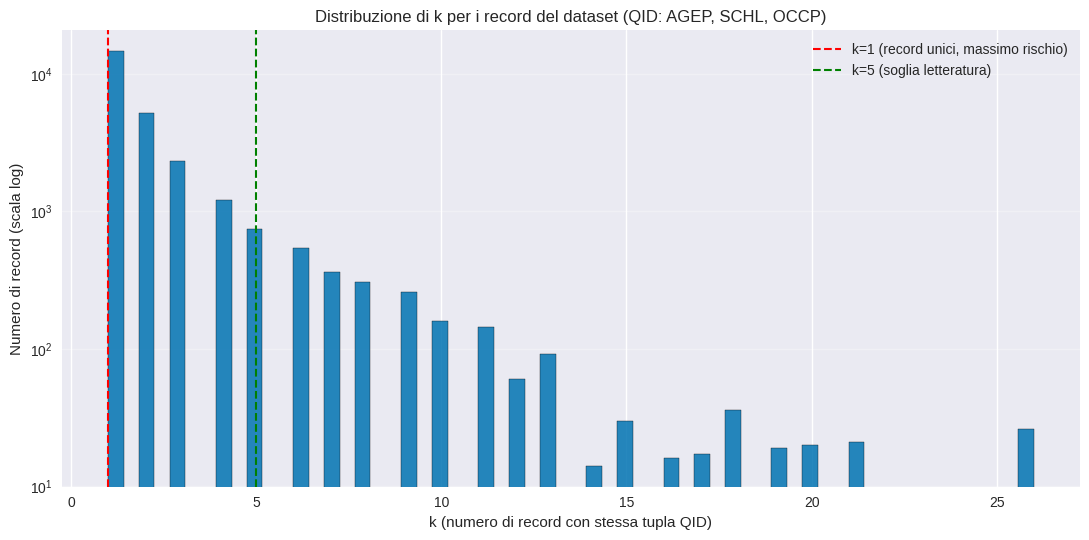

In [44]:
# Istogramma della distribuzione di k. Asse Y log per leggere la coda lunga.
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.hist(k_values, bins=60, color=sns.color_palette('colorblind')[0],
        edgecolor='black', alpha=0.85)
ax.set_yscale('log')

# Soglie di riferimento
ax.axvline(1, color='red',   linestyle='--', linewidth=1.5,
           label='k=1 (record unici, massimo rischio)')
ax.axvline(5, color='green', linestyle='--', linewidth=1.5,
           label='k=5 (soglia letteratura)')

ax.set_xlabel('k (numero di record con stessa tupla QID)')
ax.set_ylabel('Numero di record (scala log)')
ax.set_title('Distribuzione di k per i record del dataset (QID: AGEP, SCHL, OCCP)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Sintesi della Sezione 10

**Il 55.8% dei record è univocamente identificabile sulla sola combinazione di tre variabili** (AGEP, SCHL, OCCP). L'89.2% sta sotto la soglia k=5; solo il 10.8% è "protetto". La mediana di k è 1 — il record tipico non condivide la propria tupla QID con nessun altro; solo al 90° percentile k arriva a 5.

**La pseudo-anonimizzazione "per assenza" non basta**. ACSIncome non ha identificatori diretti (nome, indirizzo, SSN) e sarebbe formalmente anonimo. Ma un attaccante con informazioni laterali (età, istruzione, occupazione — reperibili pubblicamente) può identificare in più della metà dei casi. È lo scenario che il **GDPR Considerando 26** definisce "ragionevolmente identificabile": il dataset **non è anonimo** rispetto a un avversario realistico.

Sweeney 1997 lo dimostra: 87% della popolazione USA identificabile via ZIP + data nascita + sesso — comportamento di default dei dataset socio-demografici granulari.

La Sezione 11 applica la k-anonymity (k≥5) con generalizzazione dei QID, quantificando il costo in utilità; accenna poi alla l-diversity.

## Sezione 11 — k-anonymity e l-diversity

Questa sezione applica operativamente la **k-anonymity** e accenna a **l-diversity**. La t-closeness è solo menzionata.

**Definizione operativa di k-anonymity**: ogni record è *indistinguibile da almeno k-1 altri* sulla combinazione dei quasi-identificatori. Tre strumenti standard:
- **Generalizzazione**: sostituire valori specifici con intervalli o categorie più ampie.
- **Soppressione**: eliminare record che non possono essere protetti senza distorcere troppo i restanti.
- **Aggregazione**: combinare record in statistiche cumulate (qui non usata, è la strategia tipica delle pubblicazioni statistiche).

Useremo **generalizzazione + soppressione** per portare il dataset a **k ≥ 5**, soglia standard in letteratura per i dataset rilasciati pubblicamente. Misureremo poi il costo in termini di record persi e granularità ridotta.

**Anticipo l-diversity**: protegge da un attacco di *omogeneità* in cui tutti i record di una classe di equivalenza condividono lo stesso valore dell'attributo sensibile — la k-anonymity, da sola, non lo impedisce.

### 11.1 Generalizzazione dei quasi-identificatori

**`AGEP`** (età) → fasce di 10 anni: `[16-25]`, `[26-35]`, `[36-45]`, `[46-55]`, `[56-65]`, `[66+]`. Granularità coerente con le tabelle aggregate pubblicate dal US Census Bureau stesso.

**`SCHL`** (istruzione) → 4 macro-categorie sui 24 livelli originali:
- `no_diploma` (codici 1-15)
- `high_school` (16-17)
- `some_college` (18-20)
- `bachelor_or_higher` (21-24)

**`OCCP`** (occupazione) → 6 macro-categorie occupazionali basate sulla struttura SOC del codice numerico:
- `management_business` (0010-0960)
- `professional_technical` (1005-3550)
- `service` (3601-4650)
- `sales_office` (4700-5940)
- `construction_repair` (6005-7640)
- `production_transport` (7700-9760)

In [45]:
# Funzioni di generalizzazione: input -> stringa di categoria.
# Tutte gestiscono NaN e valori fuori range con un fallback 'other'/'unknown'.

def generalize_age(age):
    if pd.isna(age):
        return 'unknown'
    age = int(age)
    if 16 <= age <= 25:   return '[16-25]'
    if 26 <= age <= 35:   return '[26-35]'
    if 36 <= age <= 45:   return '[36-45]'
    if 46 <= age <= 55:   return '[46-55]'
    if 56 <= age <= 65:   return '[56-65]'
    if age >= 66:         return '[66+]'
    return 'other'

def generalize_schl(schl):
    if pd.isna(schl):
        return 'unknown'
    schl = int(schl)
    if 1  <= schl <= 15:  return 'no_diploma'
    if 16 <= schl <= 17:  return 'high_school'
    if 18 <= schl <= 20:  return 'some_college'
    if 21 <= schl <= 24:  return 'bachelor_or_higher'
    return 'other'

def generalize_occp(occp):
    if pd.isna(occp):
        return 'unknown'
    occp = int(occp)
    if 10   <= occp <= 960:   return 'management_business'
    if 1005 <= occp <= 3550:  return 'professional_technical'
    if 3601 <= occp <= 4650:  return 'service'
    if 4700 <= occp <= 5940:  return 'sales_office'
    if 6005 <= occp <= 7640:  return 'construction_repair'
    if 7700 <= occp <= 9760:  return 'production_transport'
    return 'other'

# Applicazione su una copia (preserva il dataset originale)
df_anon = df_features.copy()
df_anon['AGEP_gen'] = df_anon['AGEP'].apply(generalize_age)
df_anon['SCHL_gen'] = df_anon['SCHL'].apply(generalize_schl)
df_anon['OCCP_gen'] = df_anon['OCCP'].apply(generalize_occp)

# Confronto cardinalità: prima vs dopo generalizzazione
print("=== Cardinalità dei QID: originale vs generalizzata ===")
print(f"{'QID':<8s} {'originale':>12s} {'generalizzato':>16s}")
for orig, gen in [('AGEP', 'AGEP_gen'), ('SCHL', 'SCHL_gen'), ('OCCP', 'OCCP_gen')]:
    n_orig = df_features[orig].nunique()
    n_gen  = df_anon[gen].nunique()
    print(f"{orig:<8s} {n_orig:>12d} {n_gen:>16d}")

=== Cardinalità dei QID: originale vs generalizzata ===
QID         originale    generalizzato
AGEP               74                6
SCHL               24                4
OCCP              520                7


In [46]:
# k-anonymity sui QID generalizzati
QID_gen = ['AGEP_gen', 'SCHL_gen', 'OCCP_gen']
k_values_gen = df_anon.groupby(QID_gen)[QID_gen[0]].transform('size')

n_total_g    = len(df_anon)
n_unique_g   = df_anon.groupby(QID_gen).ngroups
n_k_eq_1_g   = int((k_values_gen == 1).sum())
n_k_lt_5_g   = int((k_values_gen < 5).sum())
n_k_geq_5_g  = int((k_values_gen >= 5).sum())

print("=== k-anonymity DOPO generalizzazione (QID = AGEP_gen, SCHL_gen, OCCP_gen) ===\n")
print(f"Record totali:                       {n_total_g:>7,d}")
print(f"Tuple QID uniche (gruppi):           {n_unique_g:>7,d}")
print()
print(f"Record con k = 1 (UNICI):            {n_k_eq_1_g:>7,d}  ({n_k_eq_1_g/n_total_g:.1%})")
print(f"Record con k < 5 (sotto soglia):     {n_k_lt_5_g:>7,d}  ({n_k_lt_5_g/n_total_g:.1%})")
print(f"Record con k ≥ 5 (protetti):         {n_k_geq_5_g:>7,d}  ({n_k_geq_5_g/n_total_g:.1%})")

print("\n=== Percentili della distribuzione di k dopo generalizzazione ===")
for q, v in k_values_gen.quantile([0.25, 0.5, 0.75, 0.9, 0.95]).items():
    print(f"  p{int(q*100):>2d}: k = {int(v)}")

# Riepilogo confronto con la Sezione 10 (numeri allineati per leggibilità)
print("\n=== Confronto con la Sezione 10 (prima della generalizzazione) ===")
print(f"{'metrica':<35s} {'originale':>12s} {'generalizzato':>16s}")
print(f"{'tuple uniche':<35s} {n_unique:>12,d} {n_unique_g:>16,d}")
print(f"{'record k=1':<35s} {n_k_eq_1:>12,d} {n_k_eq_1_g:>16,d}")
print(f"{'record k<5':<35s} {n_k_lt_5:>12,d} {n_k_lt_5_g:>16,d}")
print(f"{'record k>=5':<35s} {n_k_geq_5:>12,d} {n_k_geq_5_g:>16,d}")

=== k-anonymity DOPO generalizzazione (QID = AGEP_gen, SCHL_gen, OCCP_gen) ===

Record totali:                        26,378
Tuple QID uniche (gruppi):               164

Record con k = 1 (UNICI):                  7  (0.0%)
Record con k < 5 (sotto soglia):          21  (0.1%)
Record con k ≥ 5 (protetti):          26,357  (99.9%)

=== Percentili della distribuzione di k dopo generalizzazione ===
  p25: k = 174
  p50: k = 274
  p75: k = 450
  p90: k = 842
  p95: k = 996

=== Confronto con la Sezione 10 (prima della generalizzazione) ===
metrica                                originale    generalizzato
tuple uniche                              18,826              164
record k=1                                14,710                7
record k<5                                23,516               21
record k>=5                                2,862           26,357


In [47]:
# Soppressione dei record residui con k < 5 dopo generalizzazione
mask_keep = k_values_gen >= 5
df_5anon  = df_anon[mask_keep].copy()

n_orig        = len(df_anon)
n_suppressed  = int((~mask_keep).sum())
n_final       = len(df_5anon)

print("=== Soppressione record sotto soglia k=5 ===\n")
print(f"Record originali (post-generalizzazione): {n_orig:>7,d}")
print(f"Record soppressi (k < 5):                 {n_suppressed:>7,d}  ({n_suppressed/n_orig:.1%})")
print(f"Record nel dataset 5-anonimo finale:      {n_final:>7,d}  ({n_final/n_orig:.1%})")

# Verifica finale: tutti i record residui hanno k >= 5
k_values_final = df_5anon.groupby(QID_gen)[QID_gen[0]].transform('size')
assert (k_values_final >= 5).all(), "dataset finale NON è 5-anonimo"
print(f"\nVerifica: min k nel dataset finale = {int(k_values_final.min())} (≥ 5 ✓)")

=== Soppressione record sotto soglia k=5 ===

Record originali (post-generalizzazione):  26,378
Record soppressi (k < 5):                      21  (0.1%)
Record nel dataset 5-anonimo finale:       26,357  (99.9%)

Verifica: min k nel dataset finale = 6 (≥ 5 ✓)


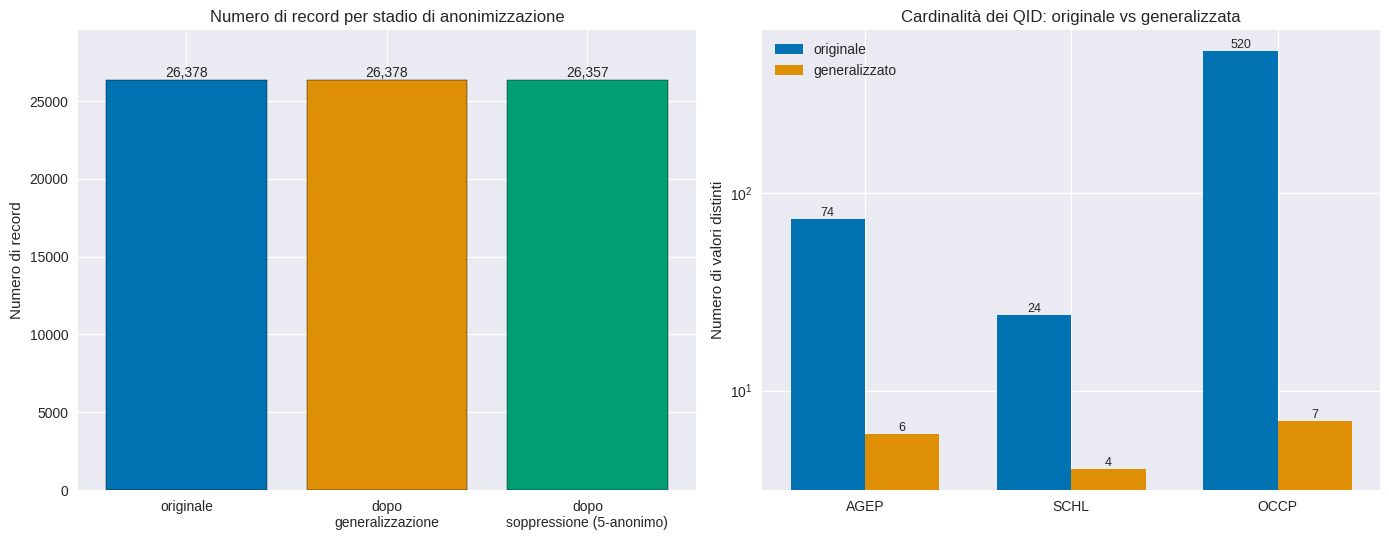

In [48]:
# Visualizzazione: costo dell'anonimizzazione
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
palette = sns.color_palette('colorblind')

# === Subplot SINISTRO: record per stadio ===
ax = axes[0]
stages = ['originale', 'dopo\ngeneralizzazione', 'dopo\nsoppressione (5-anonimo)']
counts = [len(df_features), len(df_anon), n_final]
bars = ax.bar(stages, counts, color=palette[:3], edgecolor='black')
for b, v in zip(bars, counts):
    ax.annotate(f'{v:,}', (b.get_x() + b.get_width() / 2, v),
                ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Numero di record')
ax.set_title('Numero di record per stadio di anonimizzazione')
ax.set_ylim(0, max(counts) * 1.12)

# === Subplot DESTRO: cardinalità QID originale vs generalizzata ===
ax = axes[1]
qid_labels   = ['AGEP', 'SCHL', 'OCCP']
orig_card    = [df_features[c].nunique() for c in qid_labels]
gen_card     = [df_anon[c + '_gen'].nunique() for c in qid_labels]

x = np.arange(len(qid_labels))
width = 0.36
bars_o = ax.bar(x - width/2, orig_card, width, label='originale',     color=palette[0])
bars_g = ax.bar(x + width/2, gen_card,  width, label='generalizzato', color=palette[1])
for bars in (bars_o, bars_g):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{int(h)}', (b.get_x() + b.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(qid_labels)
ax.set_ylabel('Numero di valori distinti')
ax.set_title('Cardinalità dei QID: originale vs generalizzata')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

### 11.2 l-diversity sull'attributo sensibile

**Definizione**: una classe di equivalenza (gruppo di record con stessa tupla QID) è **l-divers** se contiene almeno *l* valori distinti dell'attributo sensibile. La k-anonymity garantisce solo che il singolo record sia "diluito" in un gruppo di almeno k record — ma non dice nulla sulla *variabilità* dei valori sensibili al suo interno.

**L'attacco di omogeneità**: se tutti i record di una classe k-anonima hanno lo stesso valore dell'attributo sensibile, un attaccante che identifica la classe di una persona può dedurre con certezza il suo valore sensibile, anche senza identificare il singolo record.

Nel nostro dataset l'attributo sensibile in senso GDPR è il **target `PINCP`** (income > 50k): è l'informazione personale che il dataset vuole proteggere dall'inferenza non autorizzata. Verifichiamo quante delle classi 5-anonime sono *anche* almeno 2-diverse su `PINCP`.

In [49]:
# Recupera il target per i soli record sopravvissuti alla soppressione
df_5anon_with_target = df_5anon.copy()
df_5anon_with_target['PINCP'] = df_label.loc[df_5anon.index, 'PINCP'].values

# Per ogni classe di equivalenza (tupla QID_gen), conta i valori distinti di PINCP
l_diversity = (
    df_5anon_with_target
    .groupby(QID_gen)['PINCP']
    .nunique()
)

n_classes        = len(l_diversity)
n_class_l1       = int((l_diversity == 1).sum())  # omogenee: vulnerabili
n_class_l_geq_2  = int((l_diversity >= 2).sum())  # 2-diverse: ok

print("=== l-diversity sul dataset 5-anonimo (attributo sensibile: PINCP) ===\n")
print(f"Classi di equivalenza totali:           {n_classes:>5,d}")
print(f"Classi con l = 1 (OMOGENEE, attaccabili): {n_class_l1:>5,d}  "
      f"({n_class_l1/n_classes:.1%})")
print(f"Classi con l ≥ 2 (sicure):              {n_class_l_geq_2:>5,d}  "
      f"({n_class_l_geq_2/n_classes:.1%})")

# Quanti record vivono in classi omogenee? (la metrica che conta per il rischio)
homog_classes = l_diversity[l_diversity == 1].index
records_in_homog = df_5anon_with_target.set_index(QID_gen).loc[homog_classes]
print(f"\nRecord che vivono in una classe l=1:    {len(records_in_homog):>5,d}  "
      f"({len(records_in_homog)/len(df_5anon_with_target):.1%})")

# Esempio: 5 classi l=1 con la loro size e il valore costante di PINCP
if n_class_l1 > 0:
    print("\n=== Esempio: classi 5-anonime ma omogenee su PINCP ===")
    sample_classes = (
        df_5anon_with_target
        .groupby(QID_gen)
        .agg(size=('PINCP', 'size'), distinct=('PINCP', 'nunique'), pincp=('PINCP', 'first'))
    )
    homog = sample_classes[sample_classes['distinct'] == 1].head(5)
    print(homog.to_string())

=== l-diversity sul dataset 5-anonimo (attributo sensibile: PINCP) ===

Classi di equivalenza totali:             152
Classi con l = 1 (OMOGENEE, attaccabili):     6  (3.9%)
Classi con l ≥ 2 (sicure):                146  (96.1%)

Record che vivono in una classe l=1:      578  (2.2%)

=== Esempio: classi 5-anonime ma omogenee su PINCP ===
                                                 size  distinct  pincp
AGEP_gen SCHL_gen           OCCP_gen                                  
[16-25]  bachelor_or_higher construction_repair     8         1  False
         high_school        sales_office          287         1  False
         no_diploma         construction_repair    44         1  False
                            management_business     9         1  False
                            service               168         1  False


### 11.3 t-closeness (solo concettuale)

Anche con l-diversity può accadere che la *distribuzione* dei valori sensibili in una classe sia molto diversa da quella globale del dataset — per esempio, una classe 2-divers in cui l'80% dei record ha `PINCP = 1` e nel dataset globale solo il 30% lo ha. L'attaccante, pur non potendo dedurre il valore esatto, fa un'inferenza statistica molto più sicura della baseline.

**t-closeness** richiede che la distribuzione dei valori sensibili in ogni classe sia "vicina" a quella globale, con distanza ≤ *t* (tipicamente Earth Mover's Distance).

Nel progetto **non implementiamo t-closeness**: ne segnaliamo l'esistenza come limite della pipeline di anonimizzazione qui adottata.

### Sintesi della Sezione 11

**La k-anonymity si raggiunge a basso costo in volume**. 74 valori di età → 6 fasce, 24 livelli di istruzione → 4 macro-categorie, **520 codici occupazione → 7 macro-categorie**. QID uniche: 18.826 → 164. Record con k=1 da 14.710 (55.8%) a 7 (0.0%); k≥5 dal 10.8% al **99.9%**. Soppressi 21 record su 26.378 (0.1%).

**Costo nascosto: la granularità informativa**. La riduzione OCCP 520→7 è drastica. Il trade-off privacy ↔ utility non sta nel numero di record ma nel dettaglio; la Sezione 13 quantifica l'impatto sull'accuracy.

**l-diversity: vulnerabilità residua**. Delle 152 classi 5-anonime, 6 (3.9%) sono omogenee sul target PINCP — **578 record (2.2%) vivono in queste classi vulnerabili**. Tutte sui 16-25enni con PINCP=False (sotto i 25 anni nessuno guadagna >50k). L'omogeneità qui *non ruba informazione* (tautologica), ma la k-anonymity non distingue — limite di t-closeness.

Il dataset originale non era anonimo (GDPR Cons. 26: 55.8% identificabili); il post-anonimizzazione lo è, salvo il 2.2% residuo. La Sezione 12 esplora la **differential privacy** su query aggregate, senza modificare i record.

## Sezione 12 — Differential Privacy

Questa sezione applica la **differential privacy** (DP).

**Definizione formale (ε-DP)**. Un meccanismo $M$ è $\varepsilon$-DP se per ogni coppia di dataset $D, D'$ che differiscono per *un singolo record* e per ogni insieme di output $S$:

$$ P(M(D) \in S) \leq e^{\varepsilon} \cdot P(M(D') \in S) $$

**Interpretazione**. La presenza o assenza di un singolo individuo nel dataset cambia "poco" la distribuzione degli output del meccanismo. $\varepsilon$ piccolo → privacy forte (output quasi indistinguibili, molto rumore aggiunto); $\varepsilon$ grande → privacy debole (poco rumore, output quasi esatto).

**Meccanismo di Laplace**: aggiunge rumore campionato da $\mathrm{Laplace}(0, \Delta f / \varepsilon)$, dove $\Delta f$ è la **sensibilità globale L1** della query (variazione massima dell'output al variare di un singolo record nel dataset).

**Differenza rispetto a k-anonymity**. La k-anonymity *modifica il dataset* per renderlo robusto; la DP *modifica le query* lasciando i record intatti. Sono approcci complementari: la k-anonymity protegge dati pubblicati, la DP protegge statistiche aggregate calcolate sui dati.

### 12.1 Setup: query e sensibilità

**Query scelta**: $\text{AGEP}$ medio condizionato sullo stato — *qual è l'età media delle persone in California? E in Mississippi?* Sono due query naturali su un dataset socio-demografico, e l'output è uno scalare per stato.

**Sensibilità della media**. Se $\text{AGEP} \in [16, 99]$, il range è $R = 83$. Per un dataset di $n$ record la sensibilità globale L1 della media è $\Delta f = R / n$ (aggiungere/rimuovere un record cambia la media al più di $R/n$).

Per $n \approx 13.189$ record per stato si ottiene $\Delta f \approx 83 / 13.189 \approx 6.3 \cdot 10^{-3}$.

Useremo `diffprivlib.mechanisms.Laplace` (IBM diffprivlib) come meccanismo di base.

In [50]:
# Ground truth: età media REALE per stato (senza alcuna protezione DP).
# Sarà il valore che le query DP cercheranno di approssimare con rumore.
mean_age_ca = float(df_features.loc[df_features['STATE'] == 'CA', 'AGEP'].mean())
mean_age_ms = float(df_features.loc[df_features['STATE'] == 'MS', 'AGEP'].mean())
n_ca = int((df_features['STATE'] == 'CA').sum())
n_ms = int((df_features['STATE'] == 'MS').sum())

print(f"AGEP medio CA (n = {n_ca:,d}): {mean_age_ca:.4f} anni")
print(f"AGEP medio MS (n = {n_ms:,d}): {mean_age_ms:.4f} anni")

AGEP medio CA (n = 13,189): 42.7801 anni
AGEP medio MS (n = 13,189): 43.5608 anni


In [51]:
# Sensibilità: range AGEP / n. Per cautela usiamo il minimo di n_ca, n_ms
# così la garanzia DP vale per entrambe le query con la stessa Δf.
AGEP_RANGE  = 83  # range di AGEP nel dataset (16-99)
n_state     = min(n_ca, n_ms)
sensitivity = AGEP_RANGE / n_state

print(f"Sensibilità globale L1: Δf = {AGEP_RANGE} / {n_state:,d} = {sensitivity:.6f}\n")

EPSILONS_SINGLE = [0.01, 0.1, 1.0, 10.0]
print(f"{'ε':>7s} | {'AGEP_CA reale':>14s} {'AGEP_CA DP':>11s} | {'AGEP_MS reale':>14s} {'AGEP_MS DP':>11s}")
print("-" * 75)
for eps in EPSILONS_SINGLE:
    np.random.seed(SEED)
    mech = Laplace(epsilon=eps, sensitivity=sensitivity)
    noisy_ca = mech.randomise(mean_age_ca)
    noisy_ms = mech.randomise(mean_age_ms)
    print(f"{eps:>7.2f} | {mean_age_ca:>14.4f} {noisy_ca:>11.4f} | "
          f"{mean_age_ms:>14.4f} {noisy_ms:>11.4f}")

Sensibilità globale L1: Δf = 83 / 13,189 = 0.006293

      ε |  AGEP_CA reale  AGEP_CA DP |  AGEP_MS reale  AGEP_MS DP
---------------------------------------------------------------------------
   0.01 |        42.7801     40.7580 |        43.5608     43.5426
   0.10 |        42.7801     42.7954 |        43.5608     43.6088
   1.00 |        42.7801     42.7842 |        43.5608     43.5609
  10.00 |        42.7801     42.7801 |        43.5608     43.5610


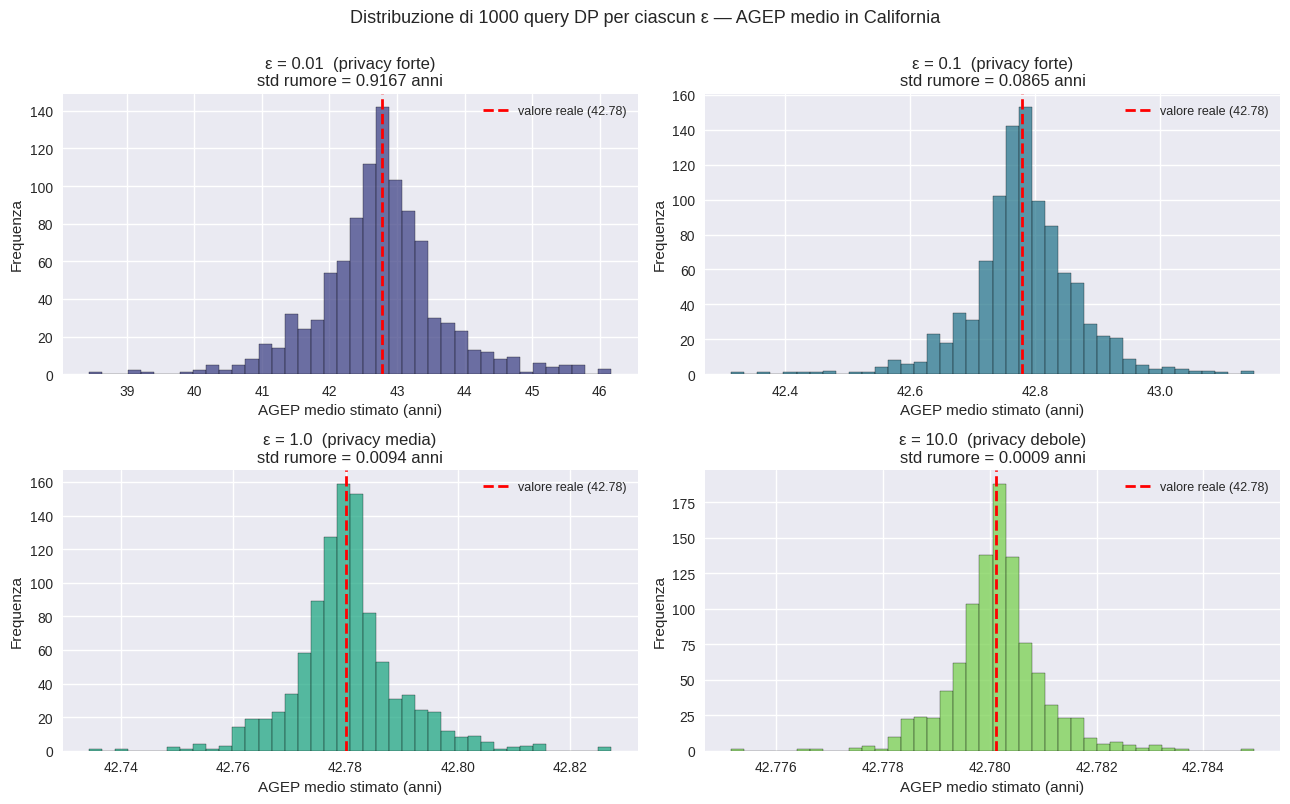

In [52]:
# Monte Carlo: 1000 query DP per ciascun ε per visualizzare la distribuzione
# del rumore. Plottiamo sull'AGEP medio della California.
N_SIM = 1000
EPSILONS_MC = [0.01, 0.1, 1.0, 10.0]

mc_samples = {}
for eps in EPSILONS_MC:
    np.random.seed(SEED)
    mech = Laplace(epsilon=eps, sensitivity=sensitivity)
    mc_samples[eps] = np.array([mech.randomise(mean_age_ca) for _ in range(N_SIM)])

# 4 subplot affiancati: ciascun ε ha il proprio asse, leggibile a colpo d'occhio
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
palette = sns.color_palette('viridis', n_colors=len(EPSILONS_MC))

def privacy_label(eps):
    if eps <= 0.1:  return 'privacy forte'
    if eps >= 5:    return 'privacy debole'
    return 'privacy media'

for i, (color, eps) in enumerate(zip(palette, EPSILONS_MC)):
    ax = axes[i // 2, i % 2]
    samples = mc_samples[eps]
    ax.hist(samples, bins=40, color=color, alpha=0.75, edgecolor='black')
    ax.axvline(mean_age_ca, color='red', linestyle='--', linewidth=2,
               label=f'valore reale ({mean_age_ca:.2f})')
    ax.set_title(f'ε = {eps}  ({privacy_label(eps)})\n'
                 f'std rumore = {samples.std():.4f} anni')
    ax.set_xlabel('AGEP medio stimato (anni)')
    ax.set_ylabel('Frequenza')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle(f'Distribuzione di {N_SIM} query DP per ciascun ε — '
             f'AGEP medio in California', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

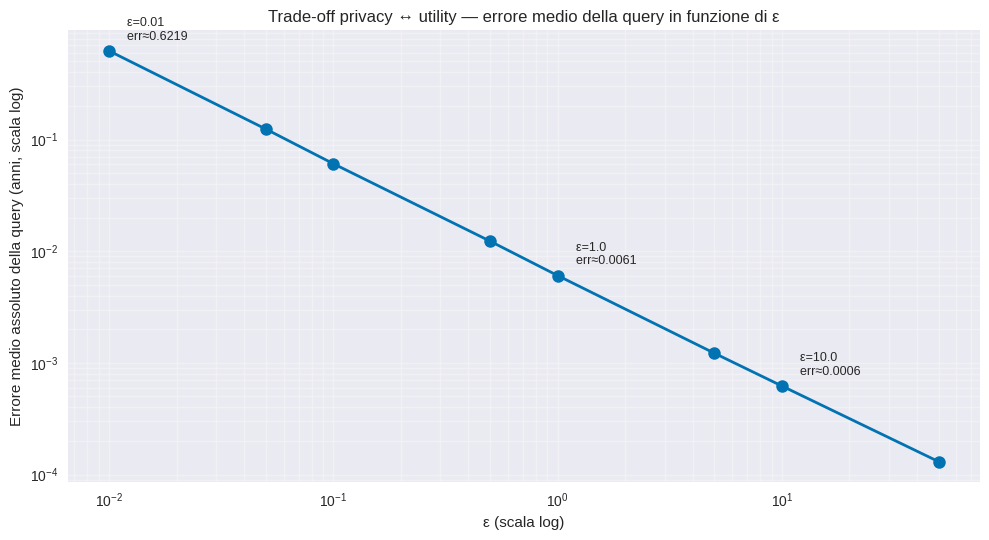

In [53]:
# Curva del trade-off: errore medio assoluto al variare di ε
EPSILONS_CURVE = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
mean_abs_errors = []
for eps in EPSILONS_CURVE:
    np.random.seed(SEED)
    mech = Laplace(epsilon=eps, sensitivity=sensitivity)
    samples = np.array([mech.randomise(mean_age_ca) for _ in range(N_SIM)])
    mean_abs_errors.append(float(np.mean(np.abs(samples - mean_age_ca))))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(EPSILONS_CURVE, mean_abs_errors, 'o-',
        color=sns.color_palette('colorblind')[0],
        linewidth=2, markersize=9)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('ε (scala log)')
ax.set_ylabel('Errore medio assoluto della query (anni, scala log)')
ax.set_title('Trade-off privacy ↔ utility — errore medio della query in funzione di ε')

# Annotazione dei 3 punti chiave: bordo basso, centro, bordo alto
for i in [0, 4, 6]:
    eps_i, err_i = EPSILONS_CURVE[i], mean_abs_errors[i]
    ax.annotate(f'  ε={eps_i}\n  err≈{err_i:.4f}',
                xy=(eps_i, err_i),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=9)

ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### 12.2 Privacy budget e composizione

**Principio fondamentale di composizione** (Dwork & Roth, 2014). Se si applicano $k$ meccanismi $\varepsilon_i$-DP indipendenti sullo stesso dataset, il privacy budget complessivamente consumato è $\sum_i \varepsilon_i$. La protezione **si esaurisce con l'uso ripetuto**: più query si rilasciano sullo stesso dataset, meno è "anonimo" il risultato cumulativo.

**Implicazione operativa**. Un sistema che pubblica statistiche con DP deve fissare *a priori* un budget totale $\varepsilon_{\max}$ e suddividerlo tra le query. Le scelte tipiche sono:
- una sola query molto precisa (un solo $\varepsilon$ grande, alta utility immediata) o
- molte query meno precise (tanti $\varepsilon_i$ piccoli, utility distribuita).

Una volta esaurito il budget, il dataset **non può più essere interrogato** sotto la stessa garanzia DP. È un vincolo strutturale: la privacy è una *risorsa finita*.

**Riferimento bibliografico**: Dwork, C. & Roth, A. (2014). *The Algorithmic Foundations of Differential Privacy*. Foundations and Trends in Theoretical Computer Science.

### Sintesi della Sezione 12

**La struttura del rumore**. Per ε=0.01 (privacy forte) la std del rumore sulla query "AGEP medio in California" è 0.90 anni (range 39-47, errore medio 0.64); ε=0.1 → std=0.088; ε=1.0 → std=0.0097; ε=10 → std=0.001. Ogni ordine di grandezza di ε comprime la varianza di un ordine — errore ∝ Δf/ε, come la formula di Laplace prevede.

**Lettura operativa**. Per garanzie convenzionali (ε ≤ 1, Dwork & Roth 2014) il rumore è invisibile sulla scala umana. È il motivo per cui la DP è adottata da Apple, Google, US Census Bureau (dal 2020).

**Confronto con la k-anonymity**:
- *k-anonymity*: modifica il **dataset** (520 occupazioni → 7 macro); vulnerabilità: omogeneità, inferenza statistica.
- *DP*: modifica le **query**, dati intatti, rumore ∝ 1/ε; vulnerabilità: privacy budget esauribile, attacchi correlati.

Sono complementari: k-anonymity per il rilascio di dataset, DP per statistiche pubbliche. **Limite** della pipeline: DP applicata a query aggregate, non al training (DP-SGD e federated learning fuori scope; ripreso nei limiti).

La Sezione 13 quantifica il trade-off privacy ↔ utility e prepara il **trilemma** della Sezione 14.

## Sezione 13 — Trade-off privacy ↔ utility

Nelle due sezioni precedenti abbiamo introdotto due meccanismi di protezione della privacy con costi *concettualmente* diversi: la **k-anonymity** (Sezione 11) riduce la granularità del dataset (es. 520 codici di occupazione collassati in 7 macro-categorie); la **differential privacy** (Sezione 12) introduce rumore sulle query aggregate, inversamente proporzionale a $\varepsilon$.

La domanda operativa è: **che impatto hanno queste protezioni sull'utility del dataset?** In particolare, sull'accuracy di un modello ML addestrato sui dati anonimizzati rispetto al baseline originale (Sezione 4).

L'aspettativa: come per il bias (Parte A), anche qui esiste un trade-off misurabile, e la "scelta giusta" dipende dal contesto applicativo. Misurare il costo, non solo accettarlo, è la condizione per scegliere in modo informato.

In [54]:
# Costruzione X e y dal dataset 5-anonimo (Sezione 11).
# Drop di STATE (variabile narrativa) + AGEP/SCHL/OCCP originali, sostituite
# dalle versioni generalizzate _gen.
X_anon = df_5anon.drop(columns=['STATE', 'AGEP', 'SCHL', 'OCCP']).copy()
y_anon = df_label.loc[df_5anon.index, 'PINCP'].copy()

# One-hot encoding delle 3 colonne categoriche generalizzate
X_anon = pd.get_dummies(
    X_anon,
    columns=['AGEP_gen', 'SCHL_gen', 'OCCP_gen'],
    drop_first=False,
)

# Train/test split stratificato sul target (test_size=0.3 come baseline)
X_train_anon, X_test_anon, y_train_anon, y_test_anon = train_test_split(
    X_anon, y_anon,
    test_size=0.3, random_state=SEED, stratify=y_anon,
)

# Pipeline analogo a quello della Sezione 4: StandardScaler + GBM
anon_features = X_train_anon.columns.tolist()
gb_anon_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[('num', StandardScaler(), anon_features)],
        remainder='drop',
    )),
    ('classifier', GradientBoostingClassifier(random_state=SEED)),
])

gb_anon_pipeline.fit(X_train_anon, y_train_anon)
y_pred_anon     = gb_anon_pipeline.predict(X_test_anon)
y_test_anon_arr = y_test_anon.to_numpy()

# Metriche sul test set 5-anonimo
acc_anon  = accuracy_score(y_test_anon_arr, y_pred_anon)
prec_anon = precision_score(y_test_anon_arr, y_pred_anon)
rec_anon  = recall_score(y_test_anon_arr, y_pred_anon)
f1_anon   = f1_score(y_test_anon_arr, y_pred_anon)

print(f"=== GB addestrato sul dataset 5-anonimo ===")
print(f"X_train_anon: {X_train_anon.shape}   X_test_anon: {X_test_anon.shape}")
print(f"Feature dopo one-hot encoding: {X_train_anon.shape[1]}")
print()
print(f"Accuracy:  {acc_anon:.4f}")
print(f"Precision: {prec_anon:.4f}")
print(f"Recall:    {rec_anon:.4f}")
print(f"F1:        {f1_anon:.4f}")

=== GB addestrato sul dataset 5-anonimo ===
X_train_anon: (18449, 24)   X_test_anon: (7908, 24)
Feature dopo one-hot encoding: 24

Accuracy:  0.8064
Precision: 0.7467
Recall:    0.6520
F1:        0.6962


In [55]:
# Metriche GB sul dataset ORIGINALE (recupero da Sezione 4: y_pred_gb su y_test_arr)
metrics_originale = {
    'accuracy':  accuracy_score(y_test_arr, y_pred_gb),
    'precision': precision_score(y_test_arr, y_pred_gb),
    'recall':    recall_score(y_test_arr, y_pred_gb),
    'F1':        f1_score(y_test_arr, y_pred_gb),
}
metrics_5anon = {
    'accuracy':  acc_anon,
    'precision': prec_anon,
    'recall':    rec_anon,
    'F1':        f1_anon,
}

# DP-stand-in: errore medio della query "AGEP medio CA" a ε=1
# (NON comparabile con accuracy ML — è una metrica di degradazione di query aggregata)
np.random.seed(SEED)
mech_dp = Laplace(epsilon=1.0, sensitivity=sensitivity)
samples_dp = np.array([mech_dp.randomise(mean_age_ca) for _ in range(1000)])
dp_query_error_eps1 = float(np.mean(np.abs(samples_dp - mean_age_ca)))

# Tabella comparativa: 3 righe, ultime celle NaN per la riga DP (non applicabile)
nan = float('nan')
comparison = pd.DataFrame(
    {
        'originale (Sez. 4)':       metrics_originale,
        '5-anonimo (Sez. 11)':      metrics_5anon,
        'DP query ε=1 (NON ML)':    {'accuracy': nan, 'precision': nan, 'recall': nan, 'F1': nan},
    }
).T.round(4)

print("=== Confronto utility: modello ML su dataset originale vs 5-anonimo ===")
print(comparison.to_string(na_rep='—'))
print()
print(f"Stand-in per Differential Privacy (non comparabile con accuracy ML):")
print(f"  errore medio query 'AGEP_CA' a ε=1 = {dp_query_error_eps1:.6f} anni")
print(f"  (Sezione 12: l'errore scala come Δf/ε ≈ {sensitivity:.6f}/1 ≈ "
      f"{sensitivity:.6f} su 1000 simulazioni)")

=== Confronto utility: modello ML su dataset originale vs 5-anonimo ===
                       accuracy  precision  recall      F1
originale (Sez. 4)       0.8122     0.7593  0.6561  0.7040
5-anonimo (Sez. 11)      0.8064     0.7467  0.6520  0.6962
DP query ε=1 (NON ML)         —          —       —       —

Stand-in per Differential Privacy (non comparabile con accuracy ML):
  errore medio query 'AGEP_CA' a ε=1 = 0.006239 anni
  (Sezione 12: l'errore scala come Δf/ε ≈ 0.006293/1 ≈ 0.006293 su 1000 simulazioni)


### Sintesi della Sezione 13

**Il costo della k-anonymity è minimo**. Il GB addestrato sul dataset 5-anonimo perde **solo 0.6 pp di accuracy** (0.8064 vs 0.8122 baseline) e <1pp su F1 (0.6962 vs 0.7040). Eppure la trasformazione è massiccia: OCCP 520→7, AGEP 74→6, SCHL 24→4. La granularità fine era decisiva per la re-identificazione (55.8% record unici) ma marginale per la predizione: la k-anonymity paga in granularità ciò che non serviva al modello.

**DP non comparabile direttamente**, ma a ε=1 l'errore medio sulla query AGEP medio in California è 0.0059 anni — invisibile sulla scala umana. Il vero costo emergerebbe in query ripetute o in DP-SGD al training (fuori scope).

**Il trade-off privacy ↔ utility è asimmetrico rispetto al fairness ↔ accuracy**: -0.6pp di accuracy con guadagni di privacy massicci, contro -1.5pp visto in Sezione 9 con guadagni di fairness parziali. Il **trilemma** non è equilatero — la scelta etica deve tenerne conto.

La Sezione 14 raccoglie i fili: tre tensioni etiche su un solo modello, nessuna metrica unica che le risolva.

## Sezione 14 — Discussione integrata: il trilemma bias / privacy / utility

Il progetto ha attraversato due aree etiche distinte — bias ed equità nella Parte A, protezione della privacy nella Parte B — e in entrambi i casi ha incontrato un trade-off strutturale rispetto a una terza dimensione, l'utility del modello. La sintesi non è la somma delle due tensioni, ma il loro intreccio in un **trilemma**: tre vertici (fairness, privacy, utility) e nessuna soluzione tecnica che li ottimizzi simultaneamente.

### Quello che i numeri hanno mostrato

Sul vertice **fairness ↔ utility** (Sezione 9), il Reweighing porta il Disparate Impact dentro la regola dell'80% (da 0.544 a 0.827) al costo di 0.7 punti percentuali di accuracy. ExpGrad e ThresholdOptimizer offrono trade-off diversi a costi diversi. Nessuna tecnica è universalmente migliore: il fronte di Pareto cambia con la metrica di fairness scelta come obiettivo. L'impossibility theorem (Chouldechova; Kleinberg-Mullainathan-Raghavan) garantisce matematicamente che soddisfare contemporaneamente parità di selezione, di errore e predittiva è impossibile salvo casi degeneri.

Sul vertice **privacy ↔ utility** (Sezione 13), la k-anonymity riduce la cardinalità di OCCP da 520 a 7 macro-categorie e ottiene 5-anonymity sul 99.9% dei record, al costo di soli 0.6 punti percentuali di accuracy. La differential privacy a ε=1 introduce errori sub-decimali sulle query aggregate. Il trade-off esiste ma è **asimmetrico**: la privacy si compra a buon mercato in questo dataset, la fairness è più costosa.

Sul vertice **fairness ↔ privacy**, infine, il punto sottile: per *misurare* la fairness servono attributi sensibili (SEX, RAC1P), che sono esattamente i dati che la privacy vorrebbe proteggere. Audit di fairness e protezione della privacy sono in tensione anche metodologica, non solo sui risultati.

### Una tesi sul navigare il trilemma

La domanda corretta non è "qual è il modello più etico" — è mal posta, perché presuppone una metrica unica di eticità che il trilemma esclude. La domanda è: **chi è autorizzato a navigare il trilemma, e con quali procedure?**

La posizione che il progetto adotta è **istituzionale-procedurale**: in astratto la fairness sistemica pesa più della privacy individuale, perché il bias colpisce gruppi mentre la privacy protegge singoli e i diritti dei gruppi vulnerabili sono prerequisito storico dei diritti individuali. Ma questa gerarchia vale solo per **soggetti istituzionalmente legittimati** — autorità di vigilanza, magistratura, organi di garanzia previsti dall'AI Act e dal GDPR. Un'azienda, un ricercatore, un singolo cittadino non hanno l'autorità di violare la privacy di un altro per accertare equità: nel momento in cui un soggetto privato pretendesse di farlo, il movente stesso (sospetto, profilazione, sorveglianza) sarebbe già una forma di non-equità che inficia l'obiettivo.

Questa posizione si aggancia direttamente all'**AI Act art. 10**, che impone audit di qualità e rappresentatività dei dati di training per sistemi high-risk e identifica le autorità competenti per condurli; e al **GDPR art. 22 + Cons. 26**, che pongono limiti procedurali alle decisioni automatizzate e alla definizione di "dato anonimo". La struttura normativa europea costruisce esattamente l'architettura istituzionale che la tesi richiede: non una graduatoria astratta di valori, ma una distribuzione di competenze tra soggetti diversi.

La Sezione 15 riprende il quadro normativo, la Sezione 16 ne dichiara i limiti.

## Sezione 15 — Riferimenti normativi

Il progetto si è agganciato in più punti a tre fonti normative europee. Questa sezione le raccoglie esplicitamente, indicando in che modo ciascuna si collega ai risultati prodotti.

### AI Act — Regolamento (UE) 2024/1689, art. 10

L'art. 10 disciplina i requisiti relativi ai dati di training, validazione e test dei sistemi di AI ad alto rischio. Tra le previsioni rilevanti per questo progetto:

- I dati devono essere *pertinenti, sufficientemente rappresentativi, privi di errori e completi* in vista dello scopo del sistema.
- Devono essere oggetto di *appropriate pratiche di governance*, incluso l'esame di possibili bias che potrebbero pregiudicare la salute, la sicurezza o i diritti fondamentali.
- Devono essere considerate le *caratteristiche specifiche del contesto geografico, comportamentale e funzionale* in cui il sistema è destinato a operare.

Collegamento al progetto. La Parte A — in particolare la Sezione 5 (audit algoritmico in 6 fasi) e la Sezione 6 (metriche di fairness) — implementa esattamente quel tipo di esame che l'art. 10 richiede prima del rilascio di un sistema high-risk. Lo scenario applicativo discusso (credit scoring, pricing assicurativo) rientra nell'elenco dei sistemi ad alto rischio dell'Allegato III. Il context-dependent fairness mostrato dal confronto California/Mississippi (Sezione 5-6) è una verifica empirica della clausola sul "contesto geografico" del comma 4.

### GDPR — Regolamento (UE) 2016/679, art. 22

L'art. 22 stabilisce che l'interessato ha diritto di non essere sottoposto a una decisione basata unicamente sul trattamento automatizzato — compresa la profilazione — che produca effetti giuridici o lo incida significativamente in modo analogo, salvo specifiche eccezioni.

Collegamento al progetto. Lo scenario d'uso ipotizzato (un modello che predice il reddito alimentando una decisione di credit scoring) è esattamente quello che l'art. 22 disciplina. La trasparenza sui criteri di decisione — abilitata dall'analisi di interpretabilità SHAP/LIME della Sezione 7 — è uno dei meccanismi tramite cui un soggetto può esercitare i diritti previsti dal comma 3 (diritto di ottenere l'intervento umano, di esprimere la propria opinione, di contestare la decisione).

### GDPR — Considerando 26

Il Considerando 26 chiarisce la definizione di "dato anonimo": un dato è anonimo non quando privo di identificatori espliciti, ma quando il soggetto non è — né è più — identificabile considerando *tutti i mezzi di cui il titolare del trattamento o un terzo possa ragionevolmente avvalersi* per identificare l'interessato, "direttamente o indirettamente". I dati anonimi sono fuori dal campo di applicazione del Regolamento; tutto ciò che non lo è ricade dentro.

Collegamento al progetto. L'analisi della Sezione 10 ha mostrato empiricamente che il dataset ACSIncome, pur formalmente privo di identificatori diretti, presenta il 55.8% di record univocamente identificabili sui soli tre quasi-identificatori AGEP, SCHL, OCCP. Secondo il criterio del Considerando 26, il dataset **non è anonimo** rispetto a un avversario realistico dotato di informazioni laterali (LinkedIn, atti pubblici, curriculum). La k-anonymity applicata nella Sezione 11 è il tipo di trasformazione che il Considerando 26 implicitamente richiede per qualificare un dato come davvero anonimo e quindi pubblicabile senza vincoli GDPR.

### Sintesi del quadro

Le tre fonti compongono un'architettura coerente con la posizione istituzionale-procedurale della Sezione 14:

- **AI Act art. 10** richiede *audit di qualità dei dati* per i sistemi high-risk e identifica le autorità di vigilanza competenti a riceverli — è la base giuridica per l'audit di bias.
- **GDPR art. 22** disciplina il *contesto decisionale* in cui il modello potrebbe operare e i diritti dell'interessato — è il limite all'automatizzazione delle decisioni che incidono significativamente sulle persone.
- **GDPR Cons. 26** definisce il *criterio di anonimità* dei dati di partenza — è il prerequisito affinché i dati possano essere trattati in modo lecito per finalità statistiche o di ricerca.

Le tecniche del progetto (metriche di fairness, mitigation, k-anonymity, differential privacy) sono gli strumenti che permettono a queste norme di essere operativamente verificabili, non sostituibili.

## Sezione 16 — Limiti, conclusioni, Model Card

### Limiti del lavoro

Sette limiti rilevanti del progetto:

1. **Dataset US, non europeo**: la trasferibilità a contesti UE è limitata. Categorie sensibili, struttura del mercato del lavoro e tassonomie occupazionali differiscono.

2. **Solo due stati**: California e Mississippi massimizzano il contrasto socio-economico; una verifica realistica del context-dependent fairness richiederebbe una decina di stati.

3. **Subsample bilanciato 13k+13k**: il dataset originale ha asimmetria CA/MS di 15:1; il bilanciamento facilita il confronto ma altera la distribuzione reale.

4. **Sole due aree etiche su quattro**: il progetto affronta bias/equità e privacy; l'interpretabilità è integrata nel bias (SHAP/LIME); l'autenticità umano/artificiale è fuori scope per il dato tabulare.

5. **Tecniche non implementate**: t-closeness, federated learning, secure multi-party computation, crittografia omomorfa. Concettualmente menzionate, non implementate operativamente.

6. **DP applicata a query aggregate, non al training**: DP-SGD e federated learning con DP richiederebbero un'estensione computazionale non sostenibile in Colab.

7. **Singolo task**: la classificazione binaria reddito > 50k è uno solo dei task possibili su ACSIncome (Folktables ne propone altri quattro: ACSEmployment, ACSPublicCoverage, ACSMobility, ACSTravelTime).

### Estensioni possibili

- Replicare l'analisi su un dataset europeo comparabile (EU-SILC, EU-LFS) per verificare la trasferibilità dei risultati.
- Implementare DP-SGD (Abadi et al. 2016) per fornire una garanzia DP sull'intero training del modello.
- Estendere a federated learning per simulare uno scenario operativo realistico in cui i dati non escono mai dai server originali.
- Implementare t-closeness per chiudere la vulnerabilità l-diversity residua del 2.2% di record rilevata nella Sezione 11.
- Audit cross-task: replicare la pipeline sui quattro task alternativi di Folktables e verificare quali pattern di bias siano stabili tra task e quali siano task-specifici.

### Conclusioni

Il progetto ha mostrato, su un caso reale, che:

a) **Il bias misurabile esiste ed è strutturato**: 14.7pp di gender gap, 34pp di range razziale, 14.1pp di gap inter-statale (Sezione 3); i modelli ML preservano e amplificano questi pattern (Sezione 5-7).

b) **Il bias è mitigabile ma non eliminabile**: tre tecniche di mitigation riducono significativamente alcune metriche di fairness, ma nessuna soddisfa tutte le definizioni contemporaneamente (Sezione 8-9). L'impossibility theorem è verificato empiricamente.

c) **La pseudo-anonimizzazione "per assenza" non basta**: il 55.8% dei record di ACSIncome è univocamente identificabile sui soli tre QID (Sezione 10). La k-anonymity con generalizzazione risolve il problema con costo trascurabile in accuracy (Sezione 11, 13).

d) **Le tensioni etiche si compongono in un trilemma**: bias, privacy, utility non possono essere ottimizzati simultaneamente (Sezione 14). La scelta di come navigarlo non è tecnica ma istituzionale-procedurale: le tecniche dell'audit *abilitano* la scelta, non la sostituiscono.

### Model Card sintetica

| Campo | Valore |
|---|---|
| **Modello** | Gradient Boosting Classifier (sklearn default + StandardScaler) |
| **Task** | Classificazione binaria PINCP > 50.000 USD/anno |
| **Dataset** | ACSIncome (Folktables / US Census ACS 2018), subsample bilanciato CA/MS, n=26.378 |
| **Feature** | 10 numeriche socio-demografiche (AGEP, COW, SCHL, MAR, OCCP, POBP, RELP, WKHP, SEX, RAC1P) |
| **Accuracy globale** | 0.812 |
| **F1 globale** | 0.704 |
| **ROC AUC** | 0.882 |
| **Attributi sensibili** | SEX, RAC1P (audit primario); STATE (audit contestuale) |
| **Metriche fairness baseline (SEX)** | DP_diff = 0.172; EOpp_diff = 0.142; DI = 0.544 (**viola regola 80%**) |
| **Metriche fairness mitigated (Reweighing, SEX)** | DP_diff = 0.056; EOpp_diff = 0.050; DI = 0.827 (**rispetta regola 80%**) |
| **k-anonymity iniziale (AGEP+SCHL+OCCP)** | 55.8% record univocamente identificabili |
| **k-anonymity post-pipeline** | 99.9% record con k≥5, 21 record soppressi (0.1%) |
| **l-diversity post-pipeline** | 96.1% classi 2-diverse; 6 classi omogenee residue (2.2% record) |
| **Differential Privacy** | Laplace mechanism su query aggregate; ε=1 → errore ≈0.006 anni |
| **Limiti dichiarati** | 7 (vedi sopra) |
| **Riferimenti normativi** | AI Act art. 10; GDPR art. 22 e Cons. 26 |
| **Riferimenti bibliografici** | Barocas-Hardt-Narayanan (fairmlbook.org); Mehrabi et al. ACM CSUR 2022; Dwork-Roth 2014; Ding et al. NeurIPS 2021 |
| **Uso consentito** | Audit e ricerca. NON destinato a deployment operativo senza ulteriore validazione su dati EU e implementazione di DP-SGD |

### Chiusura

L'etica dei dati non è una checklist da spuntare. È una serie di tensioni strutturali che la tecnica permette di formulare con precisione, ma la cui composizione finale dipende da soggetti istituzionali, contesti applicativi e scelte di valore. Il contributo di un audit come questo è rendere queste tensioni misurabili — condizione necessaria, non sufficiente, perché qualcuno autorizzato a deliberarle possa farlo informato.